# NSMC 감성분류 — `klue/bert-base` Fine-tuning & Bucketing 비교

한국어 영화 리뷰 감성분류(NSMC)를 `klue/bert-base`로 fine-tuning하고, **전처리·설정 개선**과 **dynamic padding / bucketing**이 성능(accuracy)과 학습 시간에 주는 영향을 비교하는 노트북입니다.
Hugging Face `Trainer`의 기본 흐름, 두 가지 데이터 로드 방식, 고정 패딩 전처리 등은 강의 예제를 참고하여 구성했습니다.

## 전체 흐름

```text
   ─▶ [STEP 1] 데이터 로드 (HF parquet / GitHub txt 직접 가공) ─▶ 데이터 이해(EDA)
   ─▶ [STEP 2] 토크나이저·모델 로드, 토큰 길이 분석(잘림 비율)
   ─▶ [STEP 3] 베이스라인 학습 (원본에 가깝게, 고정 패딩 128)
   ─▶ [STEP 4] 전처리(중복·결측 제거) + 설정 개선  →  validation accuracy 90% 이상 목표
   ─▶ [STEP 5] dynamic padding / bucketing 적용 후 STEP 4와 비교 (seed 3회 반복)
   ─▶ 결과 분석 (성능–시간 trade-off)
```

## 실험 구성 (총 10 run)

| 그룹 | 전처리 | 패딩 | 배치 샘플링 | seed | run 수 | 역할 |
|---|---|---|---|---|---|---|
| `base_fixed` | 최소 처리 | 고정 128 | random | 1개 | 1 | STEP 3: 베이스라인 |
| `impr_fixed` | 중복·결측 제거 | 고정 128 | random | 3개 | 3 | STEP 4: 개선본 (STEP 5의 기준선) |
| `impr_dynamic` | 중복·결측 제거 | dynamic | random | 3개 | 3 | STEP 5: dynamic padding **만** 적용 |
| `impr_bucket` | 중복·결측 제거 | dynamic | `group_by_length` | 3개 | 3 | STEP 5: dynamic padding + bucketing |

`impr_dynamic`을 따로 둔 이유: 시간 절감이 **dynamic padding** 덕인지 **bucketing(길이별 묶기)** 덕인지 분리해서 보기 위해서입니다.
STEP 5의 세 그룹(`impr_fixed` → `impr_dynamic` → `impr_bucket`)은 **패딩·샘플링 방식만** 다르고 모델·전처리·하이퍼파라미터·seed는 같습니다.

> 학습 데이터는 분할 후 train의 **`TRAIN_FRACTION`(기본 0.5)만 사용**합니다. validation(약 1.5만 건)과 test(5만 건)는 줄이지 않으므로 비교의 신뢰도는 유지되고, 학습 시간만 줄어듭니다 (개선 C4, 1-2 셀 각주 ⑥).
> 시간이 없어요 ㅜㅜ 잠자니까 주말이 순살치킨 되었습니다.

## 사용 방법

1. **위에서부터 순서대로 실행**합니다. 별도의 시험 실행(디버그)은 필요 없습니다. 대신 **6-3 사전 점검(프리플라이트)** 이 본 학습 전에 2~4분 동안 ① 코드·GPU 메모리 오류 여부, ② 실제 학습 속도, ③ 예상 총 시간을 점검합니다.
2. 프리플라이트가 예산 초과로 판정하면 1-2 셀의 `TRAIN_FRACTION`(학습 데이터 비율)이나 `NUM_EPOCHS`를 조정하슈
3. ⏱ 표시 셀은 오래 걸립니다. run이 끝날 때마다 `results/<run이름>/summary.json`이 저장되므로, 커널이 죽거나 노트북을 껐다 켜도 **완료된 run은 건너뛰고**, **학습 중이던 run은 마지막 체크포인트에서 이어서**(`resume_from_checkpoint`) 진행합니다.

> **각주**
> ① 학습이 오래 걸리는 셀은 제목에 ⏱ 표시를 했습니다. 예상 시간은 6-2 셀(학습 시간 사전 추정)에서 확인할 수 있습니다(추정치이며, 실제 측정값은 학습 후 비교표에 나옵니다).
> ② 코드 주석의 `[중요]` = 결과에 직접 영향, `[변경 가능]` = 바꿔서 실험할 수 있는 값, `[환경]` = 실행 환경(OS·GPU·라이브러리 버전)에 따라 달라지는 부분입니다.

## 1. 환경 설정

라이브러리를 불러오고 실행 환경(버전·GPU·경로)을 점검합니다. 실험에 쓰는 모든 설정값은 1-2 셀 한곳에 모아 두었습니다.

> **각주**
> ① **[환경]** 예제는 Colab 기준이지만 이 노트북은 Windows 로컬 `.ipynb` 기준입니다. Colab의 `!wget`, `!mkdir` 같은 셸 명령은 Python 코드(`urllib`, `Path.mkdir`)로 바꿨습니다.


In [2]:
# ===== 1-1. 라이브러리 · 환경 점검 =====
import os, sys, gc, json, math, time, shutil, warnings, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from packaging import version

import torch
from torch.utils.data import DataLoader
import transformers, datasets
from datasets import Dataset, load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer,
                          TrainerCallback, DataCollatorWithPadding, default_data_collator, set_seed)
from transformers.trainer_utils import get_last_checkpoint
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:          # 노트북이 아닌 곳에서 실행할 때를 대비한 안전장치
    display = print

# [환경] 버전 점검: 예제와 같은 transformers v5+, datasets v4+ 가정
if version.parse(transformers.__version__) < version.parse("5.0.0"):
    raise RuntimeError(f"transformers {transformers.__version__} → v5 이상이 필요합니다: pip install -U transformers")
if version.parse(datasets.__version__) < version.parse("4.0.0"):
    raise RuntimeError(f"datasets {datasets.__version__} → v4 이상이 필요합니다: pip install -U datasets")

# [환경] GPU 확인 — fp16은 CUDA에서만 가능
ALLOW_CPU = False                     # [환경] GPU 없이 강제로 돌리려면 True (매우 느림)
USE_CUDA = torch.cuda.is_available()
FP16 = USE_CUDA                       # [중요][개선 C1] NVIDIA GPU에서는 fp16 혼합정밀을 켠다 (속도↑, 메모리↓)
print(f"torch {torch.__version__} | transformers {transformers.__version__} | datasets {datasets.__version__}")
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | VRAM {p.total_memory / 1024**3:.1f} GB | fp16 사용")
elif not ALLOW_CPU:                   # 몇 시간짜리 학습을 CPU로 시작하는 실수를 막는다
    raise RuntimeError("CUDA GPU를 찾지 못했습니다. PyTorch CUDA 빌드가 설치됐는지 확인하세요 "
                       "(https://pytorch.org/get-started/locally/). 강제로 돌리려면 ALLOW_CPU=True")
else:
    print("⚠️ CPU로 실행합니다 (매우 느림)")

# [환경] 그래프 한글 폰트 (Windows는 Malgun Gothic)
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _f in _installed:
        plt.rcParams["font.family"] = _f
        break
else:
    print("⚠️ 한글 폰트를 찾지 못해 그래프의 한글이 깨질 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# [환경] 작업 폴더 (코드·데이터·결과가 이 아래에 저장됨)
BASE_DIR = Path(r"C:\Users\singf\Desktop\Naiffel\Huggingface_09.17")
if not BASE_DIR.exists():
    BASE_DIR = Path.cwd()             # 다른 PC/서버에서 실행하면 현재 폴더 사용
print("작업 폴더:", BASE_DIR)

torch 2.5.1+cu121 | transformers 5.17.0 | datasets 5.0.1
GPU: NVIDIA GeForce RTX 4060 | VRAM 8.0 GB | fp16 사용
작업 폴더: C:\Users\singf\Desktop\Naiffel\Huggingface_09.17


In [3]:
# ===== 1-2. 실험 설정 (여기만 바꾸면 전체 실험이 바뀝니다) =====
MODEL_NAME   = "klue/bert-base"
MAX_LENGTH   = 128        # [중요][개선 C2] 토큰 최대 길이(예제 기본은 512). 초과분은 잘림, 실제 잘림 비율은 4장에서 측정
NUM_EPOCHS   = 5          # [변경 가능] 아래 각주 참고 (BERT 논문 권장 범위는 2~4)
SEEDS        = [42, 43, 44]   # [변경 가능] STEP 5 반복 실험용 seed (학습 seed만 바뀌고 데이터 분할은 고정)
VAL_RATIO    = 0.1        # train에서 떼어 쓰는 validation 비율 (NSMC에는 validation split이 없음)
SPLIT_SEED   = 42         # [중요] 데이터 분할 seed — 모든 run에서 동일해야 비교가 공정
TRAIN_BS     = 32         # [변경 가능/환경] 8GB VRAM에서 OOM이 나면 16으로 줄이고 gradient_accumulation_steps=2 사용
EVAL_BS      = 128
PAD_MULTIPLE = 8          # [변경 가능] dynamic padding 시 길이를 8의 배수로 맞춤 (fp16 Tensor Core 정렬)
LOGGING_STEPS = 200
GRAD_ACCUM   = 1          # [변경 가능/환경] OOM이면 TRAIN_BS=16 + GRAD_ACCUM=2 (유효 배치 32 유지)

# [중요][개선 C4] 시간 예산 관리 — 학습 데이터가 커서 시간이 길기 때문에 train을 줄여서 사용
TRAIN_FRACTION    = 0.5   # [변경 가능] 분할 후 train 중 사용할 비율 (0.5 = 절반, 0.75 = 75%, 1.0 = 전체)
TIME_BUDGET_HOURS = 7     # 전체 실험 완료 목표(최대). 6-3 프리플라이트가 이 값과 비교해 판정

# [변경 가능] 하이퍼파라미터: 베이스라인 vs 개선본
#  - 개선본 값은 '가설'입니다. 베이스라인 결과(학습곡선)를 본 뒤 필요하면 수정하세요.
#  - 개선본 run을 이미 돌린 뒤 값을 바꾸면 설정이 달라진 run은 자동으로 _archive로 옮기고 다시 학습합니다.
BASE_CFG     = dict(learning_rate=2e-5, warmup_steps=0,   weight_decay=0.01)   # warmup 없음
IMPROVED_CFG = dict(learning_rate=3e-5, warmup_steps=0.1, weight_decay=0.01)   # warmup 10% + lr 3e-5

# 디버그 / 편의 스위치
DEBUG_SUBSET = None       # (선택) 예: 3000 → 전체를 축소해 빠르게 점검 (결과는 results_debug/ 에 저장). 기본은 사용 안 함
FORCE_RERUN  = False      # True면 이미 끝난 run도 다시 학습
CLEAN_CHECKPOINTS = True  # run 종료 후 체크포인트(약 1.3GB/개) 삭제로 디스크 절약
DROP_CONFLICTING_LABELS = False   # True면 '같은 문장인데 라벨이 다른' 문서를 통째로 제거 (추가 실험용)

LABEL2ID = {"부정": 0, "긍정": 1}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / ("results_debug" if DEBUG_SUBSET else "results")
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# [환경][개선 C9] 디스크 여유 점검 — run 1개가 체크포인트 최대 약 2.6GB + 모델 캐시/데이터 캐시를 쓴다
_free_gb = shutil.disk_usage(BASE_DIR).free / 1024**3
print(f"디스크 여유: {_free_gb:.1f} GB", "" if _free_gb >= 10 else "← ⚠️ 10GB 미만: 체크포인트 저장 중 실패할 수 있습니다")
print(f"모델: {MODEL_NAME} | max_length={MAX_LENGTH} | epochs={NUM_EPOCHS} | seeds={SEEDS} | debug={DEBUG_SUBSET}")
if DEBUG_SUBSET:
    print(f"⚠️ 디버그 모드: 데이터를 {DEBUG_SUBSET}건으로 줄였고 결과는 {RESULTS_DIR.name}/ 에 저장됩니다. 본 실험 전에 DEBUG_SUBSET=None 으로 되돌리세요.")

디스크 여유: 43.5 GB 
모델: klue/bert-base | max_length=128 | epochs=5 | seeds=[42, 43, 44] | debug=None


> **각주 (설정값 근거)**
> ① **에폭 수(`NUM_EPOCHS = 5`)** — BERT 원 논문 부록 A.3은 fine-tuning에 잘 맞는 범위로 배치 16·32, learning rate 5e-5·3e-5·2e-5, **에폭 2·3·4**를 제시하고, 10만 건 이상의 큰 데이터는 하이퍼파라미터에 덜 민감하다고 관찰했습니다 (Devlin et al., 2019, arXiv:1810.04805). **5에폭은 이 권장 범위를 1에폭 넘긴 값으로, 5에폭을 직접 뒷받침하는 논문은 없습니다.** 여기서는 과적합이 시작되는 시점을 학습곡선으로 직접 확인하려고 5에폭까지 학습하고, `load_best_model_at_end`로 validation accuracy가 가장 높은 에폭의 체크포인트를 사용합니다.
> ② **seed 3회 반복** — BERT fine-tuning 결과는 random seed에 따라 흔들릴 수 있다는 보고가 있습니다 (Mosbach et al., 2021, arXiv:2006.04884). 0.1~0.3%p 수준의 차이는 seed 변동과 구분하기 어려워 seed 3회의 평균과 표준편차로 비교합니다.
> ③ **`SPLIT_SEED` 고정** — validation 분할을 run마다 바꾸면 성능 차이가 '모델 차이'인지 '데이터 분할 차이'인지 알 수 없습니다. 분할은 고정하고 학습 seed만 바꿉니다.
> ④ **`PAD_MULTIPLE = 8`** — fp16 연산은 길이가 8의 배수일 때 GPU Tensor Core를 더 잘 활용합니다. dynamic padding의 시간 이득을 조금 더 크게 만들 수 있는 값이며, 1로 바꾸면 순수한 최대 길이 기준 패딩이 됩니다.
> ⑤ **[개선 A3, A4]** 개선본 하이퍼파라미터(`IMPROVED_CFG`)는 BERT fine-tuning에서 흔히 쓰는 조합(warmup 10% + 선형 감소, lr 2e-5~5e-5 범위)을 가설로 둔 것이며, 이 데이터에서 실제로 더 좋은지는 결과로 확인해야 합니다.
> ⑥ **[개선 C4] `TRAIN_FRACTION = 0.5`** — 전체 실험이 10 run이라 전체 데이터로는 7시간을 넘길 가능성이 커서 학습 데이터를 줄였습니다. **train만** 줄이고(층화 추출, 같은 seed로 고정) validation·test는 그대로 두므로 평가의 신뢰도는 유지됩니다. 대신 학습 데이터가 줄면 accuracy가 소폭 낮아질 수 있는데, 이 데이터에서 그 정도를 직접 측정하지는 않았습니다. 90%에 못 미치면 `TRAIN_FRACTION`을 올리는 것이 가장 직접적인 수단이고, 올려도 예산 안에 들어오는지는 6-3 프리플라이트가 알려 줍니다.
> ⑦ **`TIME_BUDGET_HOURS`** — 프리플라이트는 측정한 속도에 **20% 여유**를 더한 '보수적 예상 시간'이 이 값 이하일 때만 예산 내로 판정합니다.
> ⑧ **[환경] `GRAD_ACCUM`** — 배치를 반으로 줄이고 그래디언트를 2번 모으면 유효 배치는 그대로 32여서 결과가 거의 같고 메모리만 줄어듭니다. 프리플라이트에서 메모리 부족(OOM)이 나면 이 값을 바꾸세요.

## 2. STEP 1 — 데이터 로드 (두 가지 방식)

NSMC(Naver Sentiment Movie Corpus)는 영화 리뷰(`document`)와 감성 라벨(`label`: 0=부정, 1=긍정)로 이루어진 한국어 데이터셋입니다.
예제처럼 **① Hugging Face `load_dataset`으로 불러오기**와 **② 원본 txt를 내려받아 직접 가공하기**를 모두 수행하고, 두 결과가 같은지 비교합니다.

| 방식 | 출처 | 이후 사용 |
|---|---|---|
| ① 불러오기 | HF `e9t/nsmc` (parquet 변환 브랜치) | 원본 대조용 |
| ② 직접 가공 | GitHub `e9t/nsmc`의 `ratings_train.txt`, `ratings_test.txt` | **학습 파이프라인의 실제 입력** (결측·중복 처리를 직접 제어해야 하므로) |

> **각주**
> ① **[환경]** `e9t/nsmc`는 로딩 스크립트 방식 데이터셋이라 `datasets` v4 이상에서는 `revision="refs/convert/parquet"`(parquet 변환 브랜치)를 지정해야 합니다.
> ② txt 파일은 탭(`\t`) 구분이며 열은 `id`, `document`, `label`입니다. 리뷰 안에 따옴표가 들어 있어 `quoting=csv.QUOTE_NONE`으로 따옴표를 특별 취급하지 않게 읽습니다.
> ③ 두 방식의 결과가 다르면(행 수, 문장 불일치 등) 아래 비교 셀에서 바로 보이도록 했습니다. HF 로드가 실패해도(네트워크 등) txt 방식만으로 이후 단계는 진행됩니다.

In [4]:
# ===== 2-1. 방식 ①: Hugging Face load_dataset =====
# [환경] datasets v4+ 에서는 parquet 변환 브랜치를 지정해야 함
try:
    hf_nsmc = load_dataset("e9t/nsmc", revision="refs/convert/parquet")
    print(hf_nsmc)
    print("예시:", hf_nsmc["train"][0])
except Exception as e:                   # 네트워크/버전 문제가 있어도 나머지 실험은 진행 가능
    hf_nsmc = None
    print(f"HF 로드 실패 → {type(e).__name__}: {e}")

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})
예시: {'id': '9976970', 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}


In [5]:
# ===== 2-2. 방식 ②: GitHub 원본 txt 내려받기 + 직접 가공 =====
import csv

NSMC_URLS = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test":  "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
}

def download_if_needed(name, url):
    path = DATA_DIR / f"ratings_{name}.txt"
    if not path.exists():                # [환경] 방화벽으로 실패하면 브라우저로 받아 DATA_DIR에 넣어도 됨
        print(f"다운로드: {url}")
        urllib.request.urlretrieve(url, path)
    return path

def read_nsmc_txt(path):
    # [중요] QUOTE_NONE: 리뷰 속 따옴표(")를 CSV 인용부호로 해석하지 않도록 함
    return pd.read_csv(path, sep="\t", quoting=csv.QUOTE_NONE, encoding="utf-8")

train_raw = read_nsmc_txt(download_if_needed("train", NSMC_URLS["train"]))
test_raw  = read_nsmc_txt(download_if_needed("test",  NSMC_URLS["test"]))

print("train:", train_raw.shape, "| test:", test_raw.shape)
display(train_raw.head())

다운로드: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
다운로드: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
train: (150000, 3) | test: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [6]:
# ===== 2-3. 두 방식 결과 비교 (같은 데이터인가?) =====
if hf_nsmc is None:
    print("HF 데이터가 없어 비교를 건너뜁니다.")
else:
    for split, raw in [("train", train_raw), ("test", test_raw)]:
        hf_df = hf_nsmc[split].to_pandas()
        m = raw.assign(id=raw["id"].astype(str)).merge(
            hf_df.assign(id=hf_df["id"].astype(str)), on="id", how="outer", suffixes=("_txt", "_hf"), indicator=True)
        both = m[m["_merge"] == "both"]
        same_doc = (both["document_txt"].fillna("") == both["document_hf"].fillna("")).mean()
        same_lab = (both["label_txt"] == both["label_hf"]).mean()
        print(f"[{split}] txt {len(raw):,}행 / HF {len(hf_df):,}행 | id 일치 {len(both):,}행 | "
              f"문장 동일 {same_doc:.4%} | 라벨 동일 {same_lab:.4%}")

[train] txt 150,000행 / HF 150,000행 | id 일치 150,000행 | 문장 동일 99.5847% | 라벨 동일 100.0000%
[test] txt 50,000행 / HF 50,000행 | id 일치 50,000행 | 문장 동일 99.5340% | 라벨 동일 100.0000%


## 3. 데이터 이해 (EDA)

전처리를 정하기 전에 데이터의 **결측·중복·라벨 분포·길이**를 먼저 봅니다. 여기서 확인한 문제점이 5장의 전처리 정책(중복·결측 제거)의 근거가 됩니다.

확인 항목
- **결측**: `document`가 비어 있는 행 (토크나이저에 넣으면 오류가 나는 원인)
- **중복**: 같은 문장이 여러 번 등장하는 행 — 학습 데이터에 중복이 있으면 train/validation에 같은 문장이 나뉘어 들어가 **validation accuracy가 부풀려질 수 있음(데이터 누수)**
- **라벨 충돌**: 같은 문장인데 라벨이 다른 경우
- **train–test 겹침**: test 문장이 train에도 있는 경우

> **각주**
> ① 아래 표의 '중복(추가 행 수)'는 같은 문장의 **첫 번째 등장은 제외한** 나머지 행의 수입니다(= 중복 제거 시 사라지는 행 수).
> ② train–test 겹침은 이 노트북에서 제거하지 않습니다(공식 test 셋 그대로 평가). 대신 5장에서 '겹치지 않는 test 문장만의 accuracy'를 따로 계산해 참고값으로 제공합니다.

,행 수,결측(document),중복(추가 행 수),라벨 충돌 문서 수,긍정 비율,train과 겹치는 행 수
train,150000,5,3813,157,0.4988,NaN
test,50000,3,840,47,0.5035,1568.0


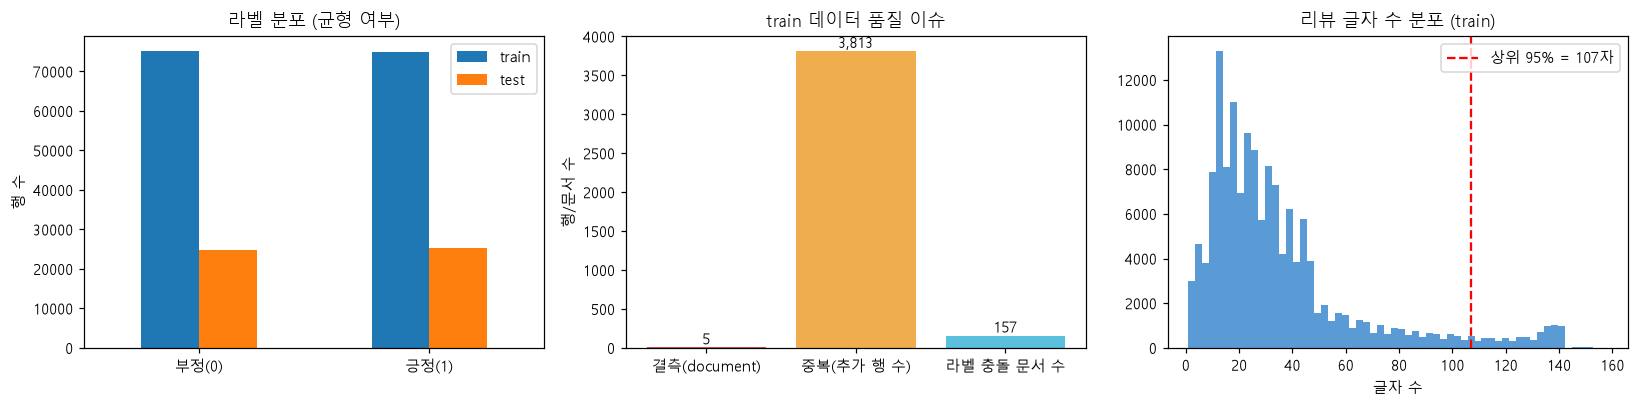

글자 수: 평균 35.2 | 중앙값 27 | 최대 158


In [7]:
# ===== 3-1. 결측 · 중복 · 라벨 충돌 · 겹침 점검 =====
def eda_table(df, ref_docs=None):
    d = df.dropna(subset=["document"])
    n_dup = int(d.duplicated(subset="document", keep="first").sum())
    n_conf = int((d.groupby("document")["label"].nunique() > 1).sum())
    row = {
        "행 수": len(df),
        "결측(document)": int(df["document"].isna().sum()),
        "중복(추가 행 수)": n_dup,
        "라벨 충돌 문서 수": n_conf,
        "긍정 비율": round(float((df["label"] == 1).mean()), 4),
    }
    if ref_docs is not None:
        row["train과 겹치는 행 수"] = int(d["document"].isin(ref_docs).sum())
    return row

train_docs_all = set(train_raw["document"].dropna())
eda_df = pd.DataFrame([eda_table(train_raw), eda_table(test_raw, train_docs_all)], index=["train", "test"])
display(eda_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
# (a) 라벨 분포
lab = pd.DataFrame({"train": train_raw["label"].value_counts().sort_index(),
                    "test":  test_raw["label"].value_counts().sort_index()})
lab.index = ["부정(0)", "긍정(1)"]
lab.plot.bar(ax=axes[0], rot=0); axes[0].set_title("라벨 분포 (균형 여부)"); axes[0].set_ylabel("행 수")
# (b) 데이터 품질 이슈(train)
issues = eda_df.loc["train", ["결측(document)", "중복(추가 행 수)", "라벨 충돌 문서 수"]]
axes[1].bar(issues.index, issues.values, color=["#d9534f", "#f0ad4e", "#5bc0de"])
axes[1].set_title("train 데이터 품질 이슈"); axes[1].set_ylabel("행/문서 수")
for i, v in enumerate(issues.values): axes[1].text(i, v, f"{int(v):,}", ha="center", va="bottom")
# (c) 글자 수 분포
char_len = train_raw["document"].dropna().str.len()
axes[2].hist(char_len, bins=60, color="#5b9bd5")
axes[2].axvline(char_len.quantile(0.95), color="red", ls="--", label=f"상위 95% = {char_len.quantile(0.95):.0f}자")
axes[2].set_title("리뷰 글자 수 분포 (train)"); axes[2].set_xlabel("글자 수"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"글자 수: 평균 {char_len.mean():.1f} | 중앙값 {char_len.median():.0f} | 최대 {char_len.max()}")

**읽는 법 / 리뷰 포인트**
- 라벨은 거의 1:1로 균형이라 accuracy를 지표로 써도 무리가 없습니다.
- 결측은 소수이지만 그대로 두면 토크나이저 입력 단계에서 오류가 납니다.
- 중복이 수천 건 규모라면 train/validation 분할 시 **같은 문장이 양쪽에 들어가** validation accuracy가 실제보다 높게 나올 수 있습니다 → 개선본에서 제거합니다.
- 글자 수 분포가 짧은 쪽에 몰려 있다면 **고정 패딩(128)은 대부분 패딩 토큰**이라는 뜻이고, 이것이 9장 bucketing 실험의 동기입니다.

## 4. STEP 2 — 토크나이저·모델 로드, 토큰 길이 분석

`klue/bert-base`의 토크나이저와 모델을 불러옵니다. 예제처럼 문장을 토큰으로 나눠 보고, **전체 train 리뷰의 토큰 길이 분포와 `MAX_LENGTH`(128) 초과로 잘리는 비율**을 측정합니다.

> **각주**
> ① 글자 수와 토큰 수는 다릅니다. 한국어는 형태소·어절이 여러 WordPiece로 쪼개지므로 글자 수보다 토큰 수가 대체로 (조금) 적거나 비슷하지만, 정확한 값은 토크나이저로 재봐야 합니다.
> ② `[CLS]`, `[SEP]` 2개가 문장 앞뒤에 붙으므로 길이에 항상 +2가 포함됩니다.
> ③ **[중요]** 모델을 불러올 때 `Some weights ... newly initialized` 경고가 나오는 것은 정상입니다. 분류 헤드(`classifier`)는 사전학습 가중치에 없어서 무작위로 초기화되고, fine-tuning에서 학습됩니다.

In [8]:
# ===== 4-1. 토크나이저 로드 + 예제 문장 나눠보기 =====
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("토크나이저 클래스:", tokenizer.__class__.__name__, "| 어휘 크기:", tokenizer.vocab_size,
      "| 모델 최대 길이:", tokenizer.model_max_length)

sample = "아 더빙.. 진짜 짜증나네요 목소리"
print("\n[tokenize]      ", tokenizer.tokenize(sample))
enc = tokenizer(sample)
print("[input_ids]     ", enc["input_ids"])
print("[token_type_ids]", enc["token_type_ids"])
print("[attention_mask]", enc["attention_mask"])
print("[decode]        ", tokenizer.decode(enc["input_ids"]))

c:\Users\singf\Desktop\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\singf\.cache\huggingface\hub\models--klue--bert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


토크나이저 클래스: BertTokenizer | 어휘 크기: 32000 | 모델 최대 길이: 512

[tokenize]       ['아', '더', '##빙', '.', '.', '진짜', '짜증', '##나', '##네', '##요', '목소리']
[input_ids]      [2, 1376, 831, 2604, 18, 18, 4229, 9801, 2075, 2203, 2182, 4243, 3]
[token_type_ids] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[attention_mask] [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[decode]         [CLS] 아 더빙.. 진짜 짜증나네요 목소리 [SEP]


In [9]:
# ===== 4-2. 모델 로드 + 동작 확인 (작은 배치 1회 forward) =====
_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)   # 분류 헤드 2개(부정/긍정)
n_params = sum(p.numel() for p in _model.parameters())
print(f"모델: {_model.__class__.__name__} | 파라미터 {n_params/1e6:.1f}M")

_batch = tokenizer(train_raw["document"].fillna("").tolist()[:4], padding=True, truncation=True,
                   max_length=MAX_LENGTH, return_tensors="pt")
_out = _model(**_batch, labels=torch.tensor(train_raw["label"].tolist()[:4]))
print("입력 shape:", tuple(_batch["input_ids"].shape), "| logits shape:", tuple(_out.logits.shape),
      f"| 초기 loss ≈ {_out.loss.item():.3f} (2클래스 무작위면 ln2 ≈ 0.693 근처)")
del _model, _batch, _out; gc.collect()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28458.74it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

모델: BertForSequenceClassification | 파라미터 110.6M
입력 shape: (4, 25) | logits shape: (4, 2) | 초기 loss ≈ 0.659 (2클래스 무작위면 ln2 ≈ 0.693 근처)


131

토큰 길이 통계: {'평균': 22.3, '중앙값': 17.0, '상위 95%': 62.0, '상위 99%': 81.0, '최대': 142.0}
MAX_LENGTH=128 초과로 잘리는 문장: 2개 / 150,000개 (0.0013%)
고정 패딩(128) 시 전체 토큰 중 패딩 비율 ≈ 82.6%  ← 9장 bucketing의 절감 여지


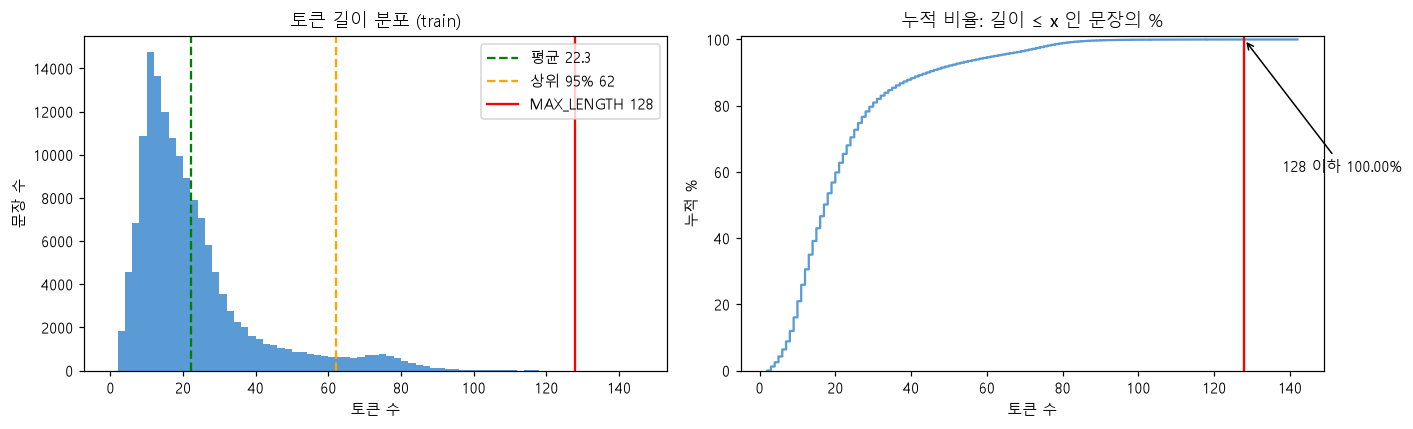


[잘리는 리뷰 예시 (앞 3개)]
 - 142토큰: 후............................................................................... ...
 - 134토큰: 선유야 사랑해 우리 좀있다가 보자!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!!♥!! ...


In [10]:
# ===== 4-3. 토큰 길이 분포 · 잘림 비율 측정 (train 전체) =====
def token_lengths(texts, chunk=10_000):
    """잘림 없이(truncation=False) 각 문장의 토큰 수([CLS],[SEP] 포함)를 잰다."""
    lens = []
    for i in range(0, len(texts), chunk):
        ids = tokenizer(texts[i:i + chunk], truncation=False, add_special_tokens=True)["input_ids"]
        lens.extend(len(x) for x in ids)
    return np.asarray(lens)

train_texts = train_raw["document"].fillna("").tolist()
tok_len = token_lengths(train_texts)

n_trunc = int((tok_len > MAX_LENGTH).sum())
stats = {
    "평균": tok_len.mean(), "중앙값": np.median(tok_len),
    "상위 95%": np.percentile(tok_len, 95), "상위 99%": np.percentile(tok_len, 99), "최대": tok_len.max(),
}
print("토큰 길이 통계:", {k: round(float(v), 1) for k, v in stats.items()})
print(f"MAX_LENGTH={MAX_LENGTH} 초과로 잘리는 문장: {n_trunc:,}개 / {len(tok_len):,}개 ({n_trunc/len(tok_len):.4%})")
pad_waste = 1 - np.minimum(tok_len, MAX_LENGTH).mean() / MAX_LENGTH
print(f"고정 패딩({MAX_LENGTH}) 시 전체 토큰 중 패딩 비율 ≈ {pad_waste:.1%}  ← 9장 bucketing의 절감 여지")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(tok_len, bins=range(0, int(tok_len.max()) + 5, 2), color="#5b9bd5")
axes[0].axvline(stats["평균"], color="green", ls="--", label=f"평균 {stats['평균']:.1f}")
axes[0].axvline(stats["상위 95%"], color="orange", ls="--", label=f"상위 95% {stats['상위 95%']:.0f}")
axes[0].axvline(MAX_LENGTH, color="red", ls="-", label=f"MAX_LENGTH {MAX_LENGTH}")
axes[0].set_title("토큰 길이 분포 (train)"); axes[0].set_xlabel("토큰 수"); axes[0].set_ylabel("문장 수"); axes[0].legend()

xs = np.sort(tok_len); ys = np.arange(1, len(xs) + 1) / len(xs) * 100
axes[1].plot(xs, ys, color="#5b9bd5")
axes[1].axvline(MAX_LENGTH, color="red"); axes[1].set_ylim(0, 101)
axes[1].set_title("누적 비율: 길이 ≤ x 인 문장의 %"); axes[1].set_xlabel("토큰 수"); axes[1].set_ylabel("누적 %")
axes[1].annotate(f"{MAX_LENGTH} 이하 {100 - n_trunc/len(tok_len)*100:.2f}%",
                 xy=(MAX_LENGTH, 100 - n_trunc/len(tok_len)*100), xytext=(MAX_LENGTH + 10, 60),
                 arrowprops=dict(arrowstyle="->"))
plt.tight_layout(); plt.show()

if n_trunc:
    print("\n[잘리는 리뷰 예시 (앞 3개)]")
    for i in np.where(tok_len > MAX_LENGTH)[0][:3]:
        print(f" - {tok_len[i]}토큰:", train_texts[i][:80], "...")
else:
    print("\n잘리는 문장이 없습니다 → MAX_LENGTH를 더 줄여도(예: 96, 64) 정보 손실이 거의 없는지 실험해 볼 수 있습니다.")

**읽는 법 / 리뷰 포인트**
- **상위 95%** 값보다 `MAX_LENGTH`가 훨씬 크면 대부분의 문장에는 **불필요한 패딩**이 붙는다는 뜻입니다(위 '고정 패딩 시 패딩 비율').
- **잘림 비율**이 0에 가까우면 128로 자르는 것이 정확도에 미치는 영향은 사실상 없다고 볼 수 있습니다. 비율이 의미 있게 크다면 `MAX_LENGTH`를 키우는 것을 고려합니다.
- 반대로 상위 99%가 128보다 한참 작다면 `MAX_LENGTH`를 줄여 고정 패딩의 낭비를 줄이는 것도 가능한 실험입니다(추가 시도로 활용 가능).

> **각주**
> ① **[변경 가능]** `MAX_LENGTH`를 바꾸면 이후 모든 토크나이징 결과가 달라지므로, 바꾼 뒤에는 5장부터 다시 실행해야 합니다.
> ② 이 통계는 **원본 train 전체(결측은 빈 문자열로 대체)** 기준입니다. 중복 제거 후의 분포도 거의 같습니다.

## 5. 전처리 정책과 데이터셋 구성

3장에서 확인한 문제(결측·중복)를 어떻게 다룰지 **베이스라인과 개선본으로 나눠** 정의합니다. 개선본에서 바뀌는 전처리는 **결측 제거와 중복 제거 두 가지뿐**입니다.

| 항목 | 베이스라인 (`baseline`) | 개선본 (`improved`) |
|---|---|---|
| 결측 `document` | 빈 문자열(`""`)로 대체 — **행은 유지** (학습이 돌아가기 위한 최소 처리) | **행 제거** (개선 A1) |
| 중복 `document` | 그대로 둠 | **첫 번째 행만 남기고 제거** (개선 A2) |
| 라벨 충돌 문서 | 그대로 둠 | 그대로 둠 (`DROP_CONFLICTING_LABELS=True`로 추가 실험 가능) |
| train / validation | 정제 후 **층화 90% / 10%** 분할 (`SPLIT_SEED` 고정) | 동일 |
| test | 결측 행만 제거, **중복은 유지** | 동일 (모든 run이 같은 test로 평가되도록) |
| 학습 데이터 양 | 분할 후 train의 `TRAIN_FRACTION`(층화)만 사용, validation은 그대로 | 동일 (개선 C4) |

> **각주**
> ① **베이스라인이 결측을 "제거"가 아니라 "빈 문자열 대체"인 이유** — 결측(NaN)을 토크나이저에 그대로 넣으면 오류가 나므로, 개선 효과를 '제거 여부'로 비교하기 위해 베이스라인은 빈 문자열로만 바꿔 학습이 돌아가게 했습니다. 결측 행은 소수라 성능에 미치는 영향은 작고, 개선 효과의 대부분은 **중복 제거**에서 나옵니다.
> ② **중복 제거는 validation 신뢰도를 바꿉니다** — 베이스라인은 중복 문장이 train과 validation에 나뉘어 들어갈 수 있어 validation accuracy가 **낙관적으로** 나올 수 있습니다. 그래서 각 run에서 '**train과 겹치지 않는 validation 문장만의 accuracy**'(`val_acc_novel`)도 함께 기록해, 개선본과 공정하게 비교할 수 있게 했습니다. 개선본에서는 중복이 없으므로 두 값이 같습니다.
> ③ **test에서 중복을 제거하지 않는 이유** — 공식 test 셋 그대로 평가해야 다른 결과와 비교할 수 있고, 모든 run이 동일한 test 문장으로 평가되어야 그룹 간 비교가 공정합니다. train과 겹치는 test 문장이 있으므로(3장 표) 겹치지 않는 문장만의 accuracy(`test_acc_novel`)도 참고값으로 기록합니다.
> ④ **[중요]** 같은 문장이 라벨만 다르게 등장하는 문서가 있는데, 중복 제거(`keep="first"`)는 그중 첫 행의 라벨만 남깁니다. 규모가 작아 그대로 두었지만 `DROP_CONFLICTING_LABELS`로 영향을 실험해 볼 수 있습니다.
> ⑤ 토크나이징은 두 가지로 만듭니다. **고정(`fixed`)**: `padding="max_length"`로 모든 문장을 128 토큰으로 맞춤(예제와 같은 방식). **동적(`dynamic`)**: 패딩 없이 저장하고, 배치를 만들 때 collator가 패딩(9장 STEP 5). 두 방식 모두 `truncation=True, max_length=128`이라 잘리는 문장은 동일합니다.

In [11]:
# ===== 5-1. 전처리 함수 · 데이터셋 빌더 =====
_BUNDLES = {}     # (prep, padding) → 데이터 묶음 캐시 (같은 조합은 한 번만 만든다)

def clean_train(df, prep):
    """prep='baseline': 결측→"" (행 유지), 중복 유지
       prep='improved': 결측 행 제거 + 중복 문장 제거(첫 행 유지)"""
    df = df.copy()
    if prep == "baseline":
        df["document"] = df["document"].fillna("")
    elif prep == "improved":
        df = df.dropna(subset=["document"])                                          # [중요][개선 A1] 결측 제거
        if DROP_CONFLICTING_LABELS:                                                    # [변경 가능] 추가 실험용
            df = df[df.groupby("document")["label"].transform("nunique") == 1]
        df = df.drop_duplicates(subset="document", keep="first")                       # [중요][개선 A2] 중복 제거
    else:
        raise ValueError(prep)
    return df.reset_index(drop=True)

def _tokenize_fn(padding):
    def fn(batch):
        return tokenizer(batch["document"], truncation=True, max_length=MAX_LENGTH,
                         padding="max_length" if padding == "fixed" else False)   # fixed: 128로 패딩 / dynamic: 패딩 안 함
    return fn

def _to_dataset(df, padding, desc):
    ds = Dataset.from_pandas(df[["document", "label"]].reset_index(drop=True), preserve_index=False)
    return ds.map(_tokenize_fn(padding), batched=True, remove_columns=["document"], desc=desc)

def build_bundle(prep, padding):
    key = (prep, padding)
    if key in _BUNDLES:
        return _BUNDLES[key]

    full = clean_train(train_raw, prep)
    n_clean = len(full)
    if DEBUG_SUBSET:                                                                   # 디버그: 빠른 점검용 축소
        full = full.sample(n=min(len(full), DEBUG_SUBSET), random_state=0).reset_index(drop=True)
    tr_df, va_df = train_test_split(full, test_size=VAL_RATIO, random_state=SPLIT_SEED, stratify=full["label"])
    n_pool = len(tr_df)                                                                # 분할 직후 train 크기(축소 전)
    if TRAIN_FRACTION < 1:                                                             # [변경 가능][개선 C4] validation은 그대로 두고 train만 축소
        tr_df, _ = train_test_split(tr_df, train_size=TRAIN_FRACTION, random_state=SPLIT_SEED, stratify=tr_df["label"])
    tr_df, va_df = tr_df.reset_index(drop=True), va_df.reset_index(drop=True)

    te_df = test_raw.dropna(subset=["document"]).reset_index(drop=True)              # test: 결측만 제거
    if DEBUG_SUBSET:
        te_df = te_df.sample(n=min(len(te_df), DEBUG_SUBSET // 2), random_state=0).reset_index(drop=True)

    # 누수 점검: validation/test 문장이 (분할된) train에 그대로 들어 있는가?
    train_docs = set(tr_df["document"])
    val_leak  = va_df["document"].isin(train_docs).to_numpy()
    test_leak = te_df["document"].isin(train_docs).to_numpy()

    bundle = dict(
        train=_to_dataset(tr_df, padding, f"tokenize train ({prep}/{padding})"),
        val=_to_dataset(va_df, padding, f"tokenize val ({prep}/{padding})"),
        test=_to_dataset(te_df, padding, f"tokenize test ({prep}/{padding})"),
        val_novel=~val_leak, test_novel=~test_leak,          # 'train과 겹치지 않는 문장' 마스크 (평가 순서와 동일)
        meta=dict(prep=prep, padding=padding, n_raw=len(train_raw), n_clean=n_clean,
                  n_train_pool=n_pool, n_train=len(tr_df), n_val=len(va_df), n_test=len(te_df),
                  val_leak=int(val_leak.sum()), test_leak=int(test_leak.sum())),
    )
    _BUNDLES[key] = bundle
    return bundle

print("전처리 함수 준비 완료")

전처리 함수 준비 완료


tokenize test (improved/dynamic): 100%|██████████| 49997/49997 [00:01<00:00, 39442.95 examples/s]


,전처리,패딩,원본 train,제거된 행,정제 후,train 풀(축소 전),train(사용),validation,test,val 중 train과 겹침,test 중 train과 겹침
0,baseline,fixed,150000,0,150000,135000,67500,15000,49997,391,1253
1,improved,fixed,150000,3818,146182,131563,65781,14619,49997,0,728
2,improved,dynamic,150000,3818,146182,131563,65781,14619,49997,0,728


샘플 입력 길이 → 고정: 128 | 동적: 11
train 컬럼: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


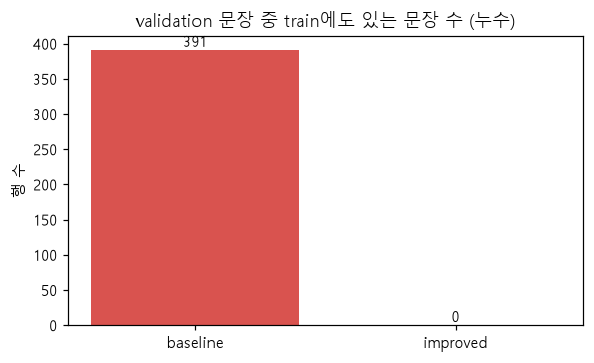

In [12]:
# ===== 5-2. ⏱ 데이터셋 3종 만들기 (토크나이징에 각각 1~2분) =====
for prep, padding in [("baseline", "fixed"), ("improved", "fixed"), ("improved", "dynamic")]:
    build_bundle(prep, padding)

rep = pd.DataFrame([b["meta"] for b in _BUNDLES.values()])
rep["제거된 행"] = rep["n_raw"] - rep["n_clean"]
rep = rep.rename(columns={"prep": "전처리", "padding": "패딩", "n_raw": "원본 train", "n_clean": "정제 후",
                          "n_train_pool": "train 풀(축소 전)", "n_train": "train(사용)", "n_val": "validation", "n_test": "test",
                          "val_leak": "val 중 train과 겹침", "test_leak": "test 중 train과 겹침"})
display(rep[["전처리", "패딩", "원본 train", "제거된 행", "정제 후", "train 풀(축소 전)", "train(사용)", "validation", "test",
             "val 중 train과 겹침", "test 중 train과 겹침"]])

# 샘플 확인: 고정 패딩 vs 동적(패딩 없음)의 길이 차이
_b_fix, _b_dyn = _BUNDLES[("improved", "fixed")], _BUNDLES[("improved", "dynamic")]
print("샘플 입력 길이 → 고정:", len(_b_fix["train"][0]["input_ids"]), "| 동적:", len(_b_dyn["train"][0]["input_ids"]))
print("train 컬럼:", _b_fix["train"].column_names)

# 누수 시각화
_leak = rep.groupby("전처리")["val 중 train과 겹침"].first()
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.bar(_leak.index, _leak.values, color=["#d9534f", "#5cb85c"])
for i, v in enumerate(_leak.values): ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
ax.set_title("validation 문장 중 train에도 있는 문장 수 (누수)"); ax.set_ylabel("행 수")
plt.tight_layout(); plt.show()

**읽는 법 / 리뷰 포인트**
- `개선본`의 'val 중 train과 겹침'이 **0**이면 중복 제거로 train↔validation 누수가 없어진 것입니다. 베이스라인은 0보다 크므로 그만큼 validation accuracy가 낙관적일 수 있습니다.
- `개선본(고정)`과 `개선본(동적)`은 **같은 행, 같은 분할**입니다(같은 전처리 + 같은 `SPLIT_SEED`). 다른 것은 패딩 방식뿐입니다.
- 동적(패딩 없음) 샘플의 길이는 문장마다 다르고, 고정은 항상 128입니다.

## 6. 학습 모듈

모든 실험이 같은 함수 `run_experiment(그룹, seed)` 하나로 실행되도록 묶었습니다. 그룹마다 바뀌는 것은 **전처리 / 패딩 / 배치 샘플링 / 하이퍼파라미터**뿐입니다.

이 함수가 하는 일
1. 모델 초기화 → `Trainer`로 학습 (에폭마다 validation 평가 + 체크포인트 저장, 마지막에 **validation 최고점 에폭의 모델**을 불러옴)
2. **에폭별 순수 학습 시간**, 학습 중 **실제 패딩 비율**, GPU 최대 메모리 기록
3. 학습이 끝난 모델로 validation·test를 다시 예측해 accuracy 계산(겹치지 않는 문장만의 accuracy 포함)
4. 결과를 `results/<run>/summary.json`으로 저장 → 다음 실행 때 자동으로 건너뜀

### 중단 후 이어하기 (`resume_from_checkpoint`)
- run 도중 커널이 죽거나 노트북을 닫아도, **같은 셀을 다시 실행**하면 `results/<run>/checkpoint-*` 중 마지막 것에서 이어서 학습합니다.
- 완료된 run은 `summary.json`이 있어 건너뜁니다. 설정(`BASE_CFG`/`IMPROVED_CFG`)이나 에폭 수를 바꾸면 이전 결과는 `results/_archive/`로 옮기고 새로 학습합니다.

> **각주**
> ① **[중요] 시간 측정 방식** — `epoch_train_sec`은 에폭 시작~끝의 순수 학습 시간(validation 평가·체크포인트 저장 제외)이며 GPU 동기화 후 잽니다. 이어서 학습한 run(`resumed=True`)은 시간이 정확하지 않아 비교표에서 시간 값을 제외합니다.
> ② **패딩 비율(`pad_ratio`)** — collator를 감싸서 학습 배치의 실제 토큰 수와 패딩 포함 토큰 수를 세어 `1 − 실제/패딩포함`으로 계산합니다(평가 배치는 제외).
> ③ **최종 예측은 Trainer 밖에서** — `group_by_length`는 평가 sampler에도 적용되어 예측 순서가 원본 순서와 달라질 수 있습니다. '겹치지 않는 문장' 마스크와 순서를 맞추기 위해 학습 후 예측은 순서가 고정된 `DataLoader`로 직접 수행합니다.
> ④ **[환경]** `dataloader_num_workers=0`으로 둡니다. Windows에서는 worker를 늘리면 프로세스 생성(spawn) 오버헤드 때문에 오히려 느려지거나 오류가 날 수 있습니다.
> ⑤ **체크포인트 용량** — BERT-base 체크포인트 1개가 옵티마이저 포함 약 1.3GB입니다. `save_total_limit=2`(최고 + 최신)로 제한하고, run이 끝나면 `CLEAN_CHECKPOINTS=True`로 삭제합니다.
> ⑥ **`load_best_model_at_end`** — 기준은 validation accuracy이고, `eval_strategy`와 `save_strategy`가 모두 `"epoch"`이어야 동작합니다.

In [13]:
# ===== 6-1. 학습 공통 모듈 =====
MODEL_COLS = ["input_ids", "token_type_ids", "attention_mask"]

def compute_metrics(eval_pred):
    """[중요] accuracy — 예제는 evaluate 라이브러리를 쓰지만, 외부 다운로드 없이 numpy로 직접 계산"""
    preds = np.argmax(eval_pred.predictions, axis=-1)
    return {"accuracy": float((preds == eval_pred.label_ids).mean())}

class CountingCollator:
    """collator를 감싸 '학습 중' 배치의 실제 토큰 수 / 패딩 포함 토큰 수를 센다."""
    def __init__(self, base):
        self.base, self.active = base, False
        self.reset()
    def reset(self):
        self.real = self.padded = self.samples = self.batches = 0
    def __call__(self, features):
        batch = self.base(features)
        if self.active:                                        # 평가 배치는 세지 않음(on_epoch_begin~end 사이만)
            self.padded += int(batch["input_ids"].numel())
            self.real += int(batch["attention_mask"].sum())
            self.samples += int(batch["input_ids"].shape[0])
            self.batches += 1
        return batch

class RunTimer(TrainerCallback):
    """에폭별 '순수 학습 시간'을 잰다 (on_epoch_end는 평가·저장보다 먼저 호출됨)."""
    def __init__(self, counter):
        self.counter, self.epoch_sec, self._t = counter, [], None
    @staticmethod
    def _sync():
        if USE_CUDA: torch.cuda.synchronize()                 # GPU 작업이 끝난 뒤 시간을 재기 위함
    def on_epoch_begin(self, args, state, control, **kwargs):
        self._sync(); self._t = time.perf_counter(); self.counter.active = True
    def on_epoch_end(self, args, state, control, **kwargs):
        self._sync(); self.epoch_sec.append(time.perf_counter() - self._t); self.counter.active = False

@torch.no_grad()
def predict_logits(model, ds, collator, batch_size=EVAL_BS):
    """순서가 고정된 DataLoader로 예측 (Trainer의 sampler와 무관)."""
    model.eval()
    dev = next(model.parameters()).device
    loader = DataLoader(ds.select_columns(MODEL_COLS + ["label"]), batch_size=batch_size,
                        shuffle=False, collate_fn=collator)
    outs, labs = [], []
    for batch in loader:
        labels = batch.pop("labels")
        batch = {k: v.to(dev) for k, v in batch.items()}
        with torch.autocast(device_type="cuda" if USE_CUDA else "cpu", dtype=torch.float16, enabled=FP16):
            logits = model(**batch).logits
        outs.append(logits.float().cpu()); labs.append(labels)
    return torch.cat(outs).numpy(), torch.cat(labs).numpy()

# ---- 실험 그룹 정의 ----
GROUPS = {
    "base_fixed":   dict(prep="baseline", padding="fixed",   sampling="random",     cfg="base",     label="베이스라인(고정패딩)"),
    "impr_fixed":   dict(prep="improved", padding="fixed",   sampling="random",     cfg="improved", label="개선본(고정패딩)"),
    "impr_dynamic": dict(prep="improved", padding="dynamic", sampling="random",     cfg="improved", label="개선본+dynamic padding"),
    "impr_bucket":  dict(prep="improved", padding="dynamic", sampling="bucketing",  cfg="improved", label="개선본+dynamic+bucketing"),
}
def _cfg_of(spec):
    return dict({"base": BASE_CFG, "improved": IMPROVED_CFG}[spec["cfg"]])      # 셀 재실행 없이 최신 설정 반영

def collect_results():
    """results/ 아래 완료된 run의 summary.json을 모두 읽는다 (_archive 폴더는 제외됨)."""
    rows = [json.loads(p.read_text(encoding="utf-8")) for p in sorted(RESULTS_DIR.glob("*/summary.json"))]
    return [r for r in rows if r["group"] in GROUPS]

def _acc(logits, labels, mask=None):
    ok = logits.argmax(-1) == labels
    if mask is not None: ok = ok[mask]
    return float(ok.mean()) if len(ok) else None

# ---- 한 번의 실험(run) ----
def run_experiment(group, seed, save_best=False, epochs=None):
    spec = GROUPS[group]
    cfg = _cfg_of(spec)
    epochs = epochs or NUM_EPOCHS
    name = f"{group}_s{seed}"
    out_dir = RESULTS_DIR / name
    summary_path = out_dir / "summary.json"

    # (a) 이미 끝난 run → 건너뜀 / 설정이 바뀜 → _archive로 옮기고 재학습
    if out_dir.exists():
        old = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else None
        same = old is not None and old.get("cfg") == cfg and old.get("num_epochs") == epochs
        if same and not FORCE_RERUN:
            print(f"✔ {name}: 이미 완료 (best val acc {old['best_val_acc']:.4f}) → 건너뜀")
            return old
        if old is not None or FORCE_RERUN:
            (RESULTS_DIR / "_archive").mkdir(exist_ok=True)
            shutil.move(str(out_dir), str(RESULTS_DIR / "_archive" / f"{name}_{int(time.time())}"))
            print(f"↺ {name}: 설정 변경/FORCE_RERUN → 이전 결과를 _archive로 옮기고 새로 학습")
    out_dir.mkdir(parents=True, exist_ok=True)

    # (b) 데이터 · 모델 · 학습 설정
    bundle = build_bundle(spec["prep"], spec["padding"])
    t_run0 = time.perf_counter()                                           # run 전체 소요시간(로드·예측 포함) 측정용
    set_seed(seed)                                                         # 분류 헤드 초기화까지 seed 고정
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)

    if spec["padding"] == "fixed":
        base_collator = default_data_collator                              # 이미 128로 패딩되어 있으므로 그대로 묶기만 함
    else:                                                                  # [중요][개선 B1, B2] 배치마다 그 배치의 최대 길이로 패딩(8의 배수로 올림)
        base_collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=PAD_MULTIPLE if FP16 else None)
    counter = CountingCollator(base_collator)
    timer = RunTimer(counter)

    args = TrainingArguments(
        output_dir=str(out_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=cfg["learning_rate"],     # [개선 A3] 개선본 3e-5 (베이스라인 2e-5)
        warmup_steps=cfg["warmup_steps"],           # [개선 A4] 개선본 0.1 = 전체 스텝의 10% (1 미만 실수는 비율, v5)
        weight_decay=cfg["weight_decay"],
        eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=2,                         # 최고 + 최신 체크포인트만 유지
        load_best_model_at_end=True, metric_for_best_model="accuracy", greater_is_better=True,   # [개선 C3] 최고 에폭 모델 사용
        # [중요][개선 B3] bucketing: 길이가 비슷한 문장끼리 배치로 묶음 (v5: group_by_length=True 대신 이 인자 사용)
        train_sampling_strategy="group_by_length" if spec["sampling"] == "bucketing" else "random",
        fp16=FP16,                                  # [환경][개선 C1] CUDA GPU에서만
        seed=seed, data_seed=seed,
        logging_steps=LOGGING_STEPS, report_to="none",
        dataloader_num_workers=0,                   # [환경] Windows에서는 0이 안전
    )
    trainer = Trainer(model=model, args=args, train_dataset=bundle["train"], eval_dataset=bundle["val"],
                      data_collator=counter, processing_class=tokenizer,
                      compute_metrics=compute_metrics, callbacks=[timer])

    # (c) 학습 (체크포인트가 있으면 이어서)
    last_ckpt = get_last_checkpoint(str(out_dir))
    if last_ckpt:
        print(f"↻ {name}: 체크포인트에서 이어서 학습 → {last_ckpt}")
    if USE_CUDA: torch.cuda.reset_peak_memory_stats()
    print(f"▶ {name} 학습 시작 | 전처리={spec['prep']} 패딩={spec['padding']} 샘플링={spec['sampling']} "
          f"seed={seed} cfg={cfg} | train {len(bundle['train']):,} / val {len(bundle['val']):,}")
    t0 = time.perf_counter()
    trainer.train(resume_from_checkpoint=last_ckpt)
    if USE_CUDA: torch.cuda.synchronize()
    wall = time.perf_counter() - t0

    # (d) 학습 로그 정리
    log = trainer.state.log_history
    val_curve = [dict(epoch=e["epoch"], eval_loss=e["eval_loss"], eval_accuracy=e["eval_accuracy"])
                 for e in log if "eval_accuracy" in e]
    train_curve = [dict(step=e["step"], epoch=e.get("epoch"), loss=e["loss"])
                   for e in log if "loss" in e and "eval_loss" not in e]
    best = max(val_curve, key=lambda d: d["eval_accuracy"])

    # (e) 학습 후 예측: validation(최고 에폭 모델) · test — 순서 고정 DataLoader
    val_logits, val_labels = predict_logits(trainer.model, bundle["val"], base_collator)
    t1 = time.perf_counter()
    test_logits, test_labels = predict_logits(trainer.model, bundle["test"], base_collator)
    test_infer_sec = time.perf_counter() - t1

    if save_best:
        trainer.save_model(str(out_dir / "best_model"))                  # 데모/추론용 (약 440MB)

    steps_per_epoch = math.ceil(len(bundle["train"]) / (TRAIN_BS * GRAD_ACCUM))
    summary = dict(
        name=name, group=group, seed=seed, prep=spec["prep"], padding=spec["padding"], sampling=spec["sampling"],
        cfg=cfg, num_epochs=epochs, max_length=MAX_LENGTH, train_bs=TRAIN_BS, fp16=FP16,
        n_train=len(bundle["train"]), n_val=len(bundle["val"]), n_test=len(bundle["test"]),
        best_epoch=best["epoch"], best_val_acc=best["eval_accuracy"], best_val_acc_trainer=trainer.state.best_metric,
        val_acc=_acc(val_logits, val_labels), val_acc_novel=_acc(val_logits, val_labels, bundle["val_novel"]),
        test_acc=_acc(test_logits, test_labels), test_acc_novel=_acc(test_logits, test_labels, bundle["test_novel"]),
        val_curve=val_curve, train_curve=train_curve,
        epoch_train_sec=[float(x) for x in timer.epoch_sec], total_train_sec=float(wall),
        test_infer_sec=float(test_infer_sec), steps_per_epoch=steps_per_epoch,
        pad_ratio=(1 - counter.real / counter.padded) if counter.padded else None,
        mean_batch_len=(counter.padded / counter.samples) if counter.samples else None,
        peak_mem_gb=(torch.cuda.max_memory_allocated() / 1024**3) if USE_CUDA else None,
        resumed=bool(last_ckpt), transformers_version=transformers.__version__,
        train_fraction=TRAIN_FRACTION, run_wall_sec=float(time.perf_counter() - t_run0),
    )
    summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

    # (f) 정리: 체크포인트 삭제, 메모리 반환
    if CLEAN_CHECKPOINTS:
        for p in out_dir.glob("checkpoint-*"):
            shutil.rmtree(p, ignore_errors=True)
    del trainer, model; gc.collect()
    if USE_CUDA: torch.cuda.empty_cache()

    mean_epoch = np.mean(timer.epoch_sec) if timer.epoch_sec else float("nan")
    print(f"✔ {name}: best val acc {summary['best_val_acc']:.4f} (epoch {summary['best_epoch']:.0f}) | "
          f"test acc {summary['test_acc']:.4f} | 에폭당 {mean_epoch/60:.1f}분 | 총 {wall/60:.1f}분")
    return summary

def plot_curves(results, title):
    """에폭별 validation accuracy / loss, 스텝별 train loss"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
    for r in results:
        v = r["val_curve"]; t = r["train_curve"]
        axes[0].plot([x["epoch"] for x in v], [x["eval_accuracy"] for x in v], marker="o", label=r["name"])
        axes[1].plot([x["epoch"] for x in v], [x["eval_loss"] for x in v], marker="o", label=r["name"])
        axes[2].plot([x["step"] for x in t], [x["loss"] for x in t], label=r["name"], alpha=0.8)
    axes[0].axhline(0.90, color="red", ls="--", lw=1, label="목표 90%")
    axes[0].set_title("validation accuracy"); axes[0].set_xlabel("epoch")
    axes[1].set_title("validation loss (오르기 시작하면 과적합 신호)"); axes[1].set_xlabel("epoch")
    axes[2].set_title("train loss"); axes[2].set_xlabel("step")
    for a in axes: a.grid(alpha=0.3); a.legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

# ---- 시간 예산 관리 (6-3 프리플라이트의 측정값 PF를 사용) ----
PF = {}          # 6-3에서 채워짐: {"fixed"|"dynamic"|"bucketing": {"it_s", "pred_sps", "save_sec", "peak_gb"}}

def project_hours(fraction, epochs, margin=1.0):
    """측정한 속도(PF)로 전체 실험 시간(시간 단위)과 그룹별 run당 분(min)을 계산."""
    total_min, per_run = 0.0, {}
    for g, spec in GROUPS.items():
        kind = "bucketing" if spec["sampling"] == "bucketing" else spec["padding"]
        meta = _BUNDLES[(spec["prep"], spec["padding"])]["meta"]
        steps = math.ceil(meta["n_train_pool"] * fraction / (TRAIN_BS * GRAD_ACCUM)) * epochs
        train_min = steps / PF[kind]["it_s"] / 60
        epoch_over = (meta["n_val"] / PF[kind]["pred_sps"] + PF[kind]["save_sec"]) / 60     # 에폭마다 평가 + 체크포인트 저장
        final_pred = (meta["n_val"] + meta["n_test"]) / PF[kind]["pred_sps"] / 60           # 학습 후 validation·test 예측
        run_min = (train_min + epochs * epoch_over + final_pred + 0.5) * margin               # +0.5: 모델 로드 등
        per_run[g] = run_min
        total_min += run_min * (1 if g == "base_fixed" else len(SEEDS))
    return total_min / 60, per_run

def budget_status(margin=1.2):
    """지금까지 쓴 시간 + 남은 예상 시간을 예산과 비교해서 보여준다 (각 ⏱ 셀 앞에서 호출)."""
    if not PF:
        print("ℹ️ 6-3 프리플라이트를 아직 실행하지 않아 시간 예상을 건너뜁니다."); return
    _, est = project_hours(TRAIN_FRACTION, NUM_EPOCHS)
    done = {r["name"]: r for r in collect_results()}
    spent = remain = 0.0
    n_done = n_all = 0
    for g in GROUPS:
        seeds = SEEDS[:1] if g == "base_fixed" else SEEDS
        walls = [done[f"{g}_s{s}"]["run_wall_sec"] / 60 for s in seeds
                 if f"{g}_s{s}" in done and done[f"{g}_s{s}"].get("run_wall_sec")]
        per_run = float(np.mean(walls)) if walls else est[g]          # 이미 끝난 같은 그룹이 있으면 실측 평균 사용
        for s in seeds:
            n_all += 1
            r = done.get(f"{g}_s{s}")
            if r is not None and r.get("run_wall_sec"):
                n_done += 1; spent += r["run_wall_sec"] / 60
            else:
                remain += per_run
    total = spent / 60 + remain * margin / 60
    ok = "✅ 예산 내" if total <= TIME_BUDGET_HOURS else "❌ 예산 초과 — TRAIN_FRACTION/NUM_EPOCHS 조정 고려"
    print(f"[시간 예산] 완료 {n_done}/{n_all} run | 누적 {spent/60:.1f}h + 남은 예상(+{round((margin-1)*100)}% 여유) {remain*margin/60:.1f}h "
          f"= {total:.1f}h / 예산 {TIME_BUDGET_HOURS}h → {ok}")

print("학습 모듈 준비 완료")

학습 모듈 준비 완료


### 6-2. 학습 시간 사전 추정 (참고용)

전체 실험이 얼마나 걸릴지 **가정**을 넣어 계산합니다. 이 표는 GPU를 돌려 보기 전의 대략적인 값이고, **바로 다음 6-3 프리플라이트가 실측 속도로 다시 계산**합니다. 실제 시간은 학습 후 비교표(10장)에서 확인합니다.

> **각주 (계산 근거 — 모두 추정치)**
> ① **스텝 수** = ⌈학습 데이터 수 ÷ 유효 배치 크기(32)⌉ × 에폭 수. (예: `TRAIN_FRACTION=0.5` → 학습 약 6.6만 건 → 에폭당 약 2,050스텝)
> ② **초당 스텝 수(it/s) 가정** — RTX 4060 8GB, fp16, 배치 32, BERT-base 기준으로 잡은 값이며 **직접 측정한 값이 아닙니다.** 고정 패딩 128: 5~8 it/s, dynamic padding(무작위 배치): 7~12 it/s, bucketing: 10~18 it/s. 문장이 짧을수록 스텝이 빨라지지만, 길이가 짧아질수록 GPU를 덜 채우고 파이썬·데이터 로딩 오버헤드가 커져 **절감 폭에는 한계가 있어** 범위를 넓게 잡았습니다.
> ③ **에폭당 오버헤드 1분 가정** — validation 평가, 체크포인트 저장(약 1.3GB 쓰기), sampler 준비 등.
> ④ 처음 실행할 때 토크나이징에 몇 분이 더 들고, 학습 중 로그의 `it/s`를 보면 가정이 맞는지 바로 확인할 수 있습니다. **첫 100스텝 정도의 `it/s`로 전체 시간을 역산**해 보세요.
> ⑤ 가정을 실제 측정값으로 바꾸려면 아래 `ASSUMED_IT_PER_SEC` 값만 고치면 됩니다. **[변경 가능]**

In [14]:
# ===== 6-2. 학습 시간 사전 추정 (가정 기반, 참고용) =====
ASSUMED_IT_PER_SEC = {"fixed": (5, 8), "dynamic": (7, 12), "bucketing": (10, 18)}   # [변경 가능] (느린 쪽, 빠른 쪽)
OVERHEAD_MIN_PER_EPOCH = 1.0                                                          # 평가·저장 등

def estimate_minutes(n_train, epochs, kind):
    steps = math.ceil(n_train / (TRAIN_BS * GRAD_ACCUM)) * epochs
    slow, fast = ASSUMED_IT_PER_SEC[kind]
    ovh = OVERHEAD_MIN_PER_EPOCH * epochs
    return steps / fast / 60 + ovh, steps / slow / 60 + ovh          # (최소, 최대)

rows = []
for g, spec in GROUPS.items():
    n_tr = build_bundle(spec["prep"], spec["padding"])["meta"]["n_train"]
    kind = "bucketing" if spec["sampling"] == "bucketing" else spec["padding"]
    lo, hi = estimate_minutes(n_tr, NUM_EPOCHS, kind)
    n_runs = 1 if g == "base_fixed" else len(SEEDS)
    rows.append({"그룹": g, "run 수": n_runs, "train 수": n_tr, "에폭당 스텝": math.ceil(n_tr / (TRAIN_BS * GRAD_ACCUM)),
                 "가정 it/s": f"{ASSUMED_IT_PER_SEC[kind][0]}~{ASSUMED_IT_PER_SEC[kind][1]}",
                 "run당 예상(분)": f"{lo:.0f}~{hi:.0f}", "그룹 합계(분)": f"{lo*n_runs:.0f}~{hi*n_runs:.0f}",
                 "_lo": lo * n_runs, "_hi": hi * n_runs})
est = pd.DataFrame(rows)
display(est.drop(columns=["_lo", "_hi"]))
print(f"전체 예상 시간(추정): {est['_lo'].sum()/60:.1f} ~ {est['_hi'].sum()/60:.1f} 시간 "
      f"(토크나이징 등 제외, 에폭={NUM_EPOCHS})")

,그룹,run 수,train 수,에폭당 스텝,가정 it/s,run당 예상(분),그룹 합계(분)
0,base_fixed,1,67500,2110,5~8,27~40,27~40
1,impr_fixed,3,65781,2056,5~8,26~39,79~118
2,impr_dynamic,3,65781,2056,7~12,19~29,58~88
3,impr_bucket,3,65781,2056,10~18,15~22,44~66


전체 예상 시간(추정): 3.5 ~ 5.2 시간 (토크나이징 등 제외, 에폭=5)


### 6-3. 사전 점검(프리플라이트) ⏱ 약 2~4분

별도의 시험 실행 없이 바로 본 학습으로 들어가므로, **몇 시간짜리 학습을 시작하기 전에** 이 셀이 실제 설정과 같은 조건(fp16, 배치 32, 세 가지 패딩·샘플링 방식)으로 **200스텝씩 짧게 학습**해 봅니다.

이 셀이 확인하는 것
1. **오류 여부** — 모델·토크나이저 로드, 학습, 평가, 체크포인트 저장, 예측 경로가 실제로 동작하는가 (Windows 경로·디스크 문제 포함)
2. **GPU 메모리** — 고정 패딩 128 + 배치 32가 8GB VRAM에 들어가는가 (부족하면 안내 후 중단)
3. **실제 속도(it/s)** — 세 방식(고정 / dynamic / bucketing)별 초당 스텝 수
4. **예상 총 시간** — 측정 속도로 `TRAIN_FRACTION` 후보별 전체 시간을 계산하고 `TIME_BUDGET_HOURS`와 비교

> **각주**
> ① **속도는 중앙값 기준** — 처음 몇 스텝(GPU 예열)은 제외하고 스텝당 시간의 중앙값으로 it/s를 잽니다. 평가·저장이 낀 스텝은 튀는 값이라 중앙값으로 걸러지고, 그 튀는 정도는 '에폭당 평가+저장 오버헤드' 추정에 씁니다.
> ② **bucketing 속도는 근사** — 점검용 표본이 6,400건이라 실제 학습(수만 건)보다 정렬 효과가 약간 다를 수 있습니다. 대신 본 학습이 진행되면 `budget_status()`가 **이미 끝난 run의 실측 시간**으로 예상을 계속 갱신합니다.
> ③ **'보수적 예상'** = 측정 기반 예상 × 1.2 (속도 변동, 발열, 다른 프로그램 사용 등을 감안한 여유 20%).
> ④ 점검이 끝나면 임시 폴더(`results/_preflight`)를 삭제합니다.

In [15]:
# ===== 6-3. ⏱ 사전 점검(프리플라이트) =====
PF_SAMPLES, PF_STEPS, PF_VAL = 6400, 200, 2000        # 점검용 학습 표본 수 / 스텝 수 / 예측 속도 측정용 validation 수
CANDIDATE_FRACTIONS = [0.5, 0.6, 0.75, 1.0]           # [변경 가능] 예상 시간을 비교해 볼 TRAIN_FRACTION 후보

class StepClock(TrainerCallback):
    """매 스텝 종료 시각을 기록해 스텝당 시간을 계산한다."""
    def __init__(self): self.t = []
    def on_step_end(self, args, state, control, **kwargs):
        if USE_CUDA: torch.cuda.synchronize()
        self.t.append(time.perf_counter())

def preflight_one(kind):
    """kind: fixed | dynamic | bucketing — 소량 학습으로 오류·메모리·속도·저장 경로를 점검"""
    padding = "fixed" if kind == "fixed" else "dynamic"
    b = build_bundle("improved", padding)
    tr = b["train"].select(range(min(PF_SAMPLES, len(b["train"]))))
    va = b["val"].select(range(min(PF_VAL, len(b["val"]))))
    pf_dir = RESULTS_DIR / "_preflight"
    shutil.rmtree(pf_dir, ignore_errors=True)

    set_seed(SEEDS[0])
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)
    collator = default_data_collator if padding == "fixed" else DataCollatorWithPadding(
        tokenizer, pad_to_multiple_of=PAD_MULTIPLE if FP16 else None)
    half = max(1, PF_STEPS // 2)                                   # 중간·끝에서 평가와 저장이 각 1번씩 일어나게 함
    args = TrainingArguments(
        output_dir=str(pf_dir), max_steps=PF_STEPS,
        per_device_train_batch_size=TRAIN_BS, gradient_accumulation_steps=GRAD_ACCUM, per_device_eval_batch_size=EVAL_BS,
        learning_rate=IMPROVED_CFG["learning_rate"], warmup_steps=IMPROVED_CFG["warmup_steps"],
        weight_decay=IMPROVED_CFG["weight_decay"],
        eval_strategy="steps", eval_steps=half, save_strategy="steps", save_steps=half, save_total_limit=1,
        train_sampling_strategy="group_by_length" if kind == "bucketing" else "random",
        fp16=FP16, seed=SEEDS[0], logging_steps=50, report_to="none",
        dataloader_num_workers=0, disable_tqdm=True)
    clock = StepClock()
    trainer = Trainer(model=model, args=args, train_dataset=tr, eval_dataset=va, data_collator=collator,
                      processing_class=tokenizer, compute_metrics=compute_metrics, callbacks=[clock])
    if USE_CUDA: torch.cuda.reset_peak_memory_stats()
    trainer.train()

    dt = np.diff(clock.t)                                          # 스텝당 시간
    steady = dt[min(20, len(dt) // 4):]                            # 처음 스텝(예열) 제외
    med = float(np.median(steady))
    t0 = time.perf_counter()
    predict_logits(trainer.model, va, collator)                    # 학습 후 예측 경로 점검 + 예측 속도 측정
    pred_sps = len(va) / (time.perf_counter() - t0)
    save_sec = min(max(float(steady.max()) - med - len(va) / pred_sps, 0.0), 120.0)   # 평가+저장 스텝의 초과 시간에서 평가분 제외
    out = dict(it_s=1.0 / med, step_ms=med * 1000, pred_sps=pred_sps, save_sec=save_sec,
               peak_gb=(torch.cuda.max_memory_allocated() / 1024**3) if USE_CUDA else float("nan"))
    del trainer, model; gc.collect()
    if USE_CUDA: torch.cuda.empty_cache()
    shutil.rmtree(pf_dir, ignore_errors=True)
    return out

PF.clear()
for _kind in ["fixed", "dynamic", "bucketing"]:
    try:
        PF[_kind] = preflight_one(_kind)
    except torch.cuda.OutOfMemoryError:
        raise RuntimeError(f"[{_kind}] GPU 메모리 부족(OOM): 1-2 셀에서 TRAIN_BS=16, GRAD_ACCUM=2 로 바꾸고 1-2 셀부터 다시 실행하세요.")
    print(f"  ✔ {_kind:9s}: {PF[_kind]['it_s']:.2f} it/s ({PF[_kind]['step_ms']:.0f} ms/스텝)")
(RESULTS_DIR / "preflight.json").write_text(json.dumps(PF, indent=2), encoding="utf-8")

display(pd.DataFrame(PF).T.rename(columns={"it_s": "초당 스텝(it/s)", "step_ms": "스텝당 ms", "pred_sps": "예측 속도(샘플/초)",
                                            "save_sec": "평가+저장 오버헤드(초/에폭)", "peak_gb": "GPU 최대 메모리(GB)"}).round(2))

# ---- 예상 총 시간: TRAIN_FRACTION 후보별 ----
rows, fr_list = [], sorted(set(CANDIDATE_FRACTIONS + [TRAIN_FRACTION]))
for f in fr_list:
    h, _ = project_hours(f, NUM_EPOCHS)
    rows.append({"TRAIN_FRACTION": f, "예상(시간)": round(h, 2), "보수적(+20%)": round(h * 1.2, 2),
                 "예산 판정": "✅ 내" if h * 1.2 <= TIME_BUDGET_HOURS else "❌ 초과",
                 "현재 설정": "◀" if f == TRAIN_FRACTION else ""})
display(pd.DataFrame(rows))

fits = [r["TRAIN_FRACTION"] for r in rows if r["보수적(+20%)"] <= TIME_BUDGET_HOURS]
cur = next(r for r in rows if r["TRAIN_FRACTION"] == TRAIN_FRACTION)
print(f"에폭 {NUM_EPOCHS}, seed {len(SEEDS)}개 기준 — 현재 TRAIN_FRACTION={TRAIN_FRACTION}: 예상 {cur['예상(시간)']}h "
      f"(보수적 {cur['보수적(+20%)']}h) / 예산 {TIME_BUDGET_HOURS}h → {cur['예산 판정']}")
print("예산 안에서 쓸 수 있는 최대 TRAIN_FRACTION:", max(fits) if fits else "없음 (NUM_EPOCHS를 줄이거나 SEEDS를 줄여야 함)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 757.18it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. 

{'loss': '0.51', 'grad_norm': '5.443', 'learning_rate': '2.533e-05', 'epoch': '0.25'}
{'loss': '0.3789', 'grad_norm': '4.234', 'learning_rate': '1.7e-05', 'epoch': '0.5'}
{'eval_loss': '0.358', 'eval_accuracy': '0.8505', 'eval_runtime': '2.81', 'eval_samples_per_second': '711.8', 'eval_steps_per_second': '5.695', 'epoch': '0.5'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.20it/s]


{'loss': '0.3363', 'grad_norm': '3.993', 'learning_rate': '8.667e-06', 'epoch': '0.75'}
{'loss': '0.3389', 'grad_norm': '7.013', 'learning_rate': '3.333e-07', 'epoch': '1'}
{'eval_loss': '0.3223', 'eval_accuracy': '0.868', 'eval_runtime': '2.654', 'eval_samples_per_second': '753.5', 'eval_steps_per_second': '6.028', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.20it/s]


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.28it/s]


{'train_runtime': '28.51', 'train_samples_per_second': '224.5', 'train_steps_per_second': '7.015', 'train_loss': '0.4012', 'epoch': '1'}
  ✔ bucketing: 8.75 it/s (114 ms/스텝)


,초당 스텝(it/s),스텝당 ms,예측 속도(샘플/초),평가+저장 오버헤드(초/에폭),GPU 최대 메모리(GB)
fixed,5.19,192.83,771.97,1.29,3.03
dynamic,6.49,153.98,907.37,1.39,2.92
bucketing,8.75,114.24,986.46,0.47,2.84


,TRAIN_FRACTION,예상(시간),보수적(+20%),예산 판정,현재 설정
0,0.50,5.05,6.07,✅ 내,◀
1,0.60,5.96,7.15,❌ 초과,
2,0.75,7.31,8.77,❌ 초과,
3,1.00,9.57,11.48,❌ 초과,


에폭 5, seed 3개 기준 — 현재 TRAIN_FRACTION=0.5: 예상 5.05h (보수적 6.07h) / 예산 7h → ✅ 내
예산 안에서 쓸 수 있는 최대 TRAIN_FRACTION: 0.5


## 7. STEP 3 — 베이스라인 학습 ⏱

**최소 전처리(결측→빈 문자열) + 고정 패딩 128 + 기본 설정(`BASE_CFG`)** 으로 `klue/bert-base`를 학습합니다. 모델과 데이터가 정상적으로 동작하는지, 학습곡선이 어떤 모양인지 확인하는 단계입니다.

> **각주**
> ① 이 run은 한 번만 실행합니다(seed = `SEEDS[0]`). STEP 4 개선의 출발점이 되는 기준선입니다.
> ② 에폭별 validation accuracy가 어느 에폭에서 최고점을 찍고 그 뒤로 정체·하락하는지 보세요. 이 곡선이 5에폭 설정의 근거를 직접 확인하는 자료입니다.
> ③ 베이스라인의 validation accuracy는 중복 누수로 **낙관적일 수 있으니**, 아래 표의 `val_acc_novel`(train과 겹치지 않는 문장만)도 함께 보세요.

In [16]:
# ===== 7-1. ⏱ STEP 3: 베이스라인 학습 =====
budget_status()
res_base = run_experiment("base_fixed", SEEDS[0])

[시간 예산] 완료 0/10 run | 누적 0.0h + 남은 예상(+20% 여유) 6.1h = 6.1h / 예산 7h → ✅ 예산 내


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1406.38it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

▶ base_fixed_s42 학습 시작 | 전처리=baseline 패딩=fixed 샘플링=random seed=42 cfg={'learning_rate': 2e-05, 'warmup_steps': 0, 'weight_decay': 0.01} | train 67,500 / val 15,000


Epoch,Training Loss,Validation Loss,Accuracy
1,0.278874,0.264569,0.894200
2,0.191497,0.282420,0.896200
3,0.116130,0.361566,0.895333
4,0.074473,0.457948,0.896800
5,0.063541,0.517358,0.896267


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.61it/s]


✔ base_fixed_s42: best val acc 0.8968 (epoch 4) | test acc 0.8969 | 에폭당 6.4분 | 총 33.8분


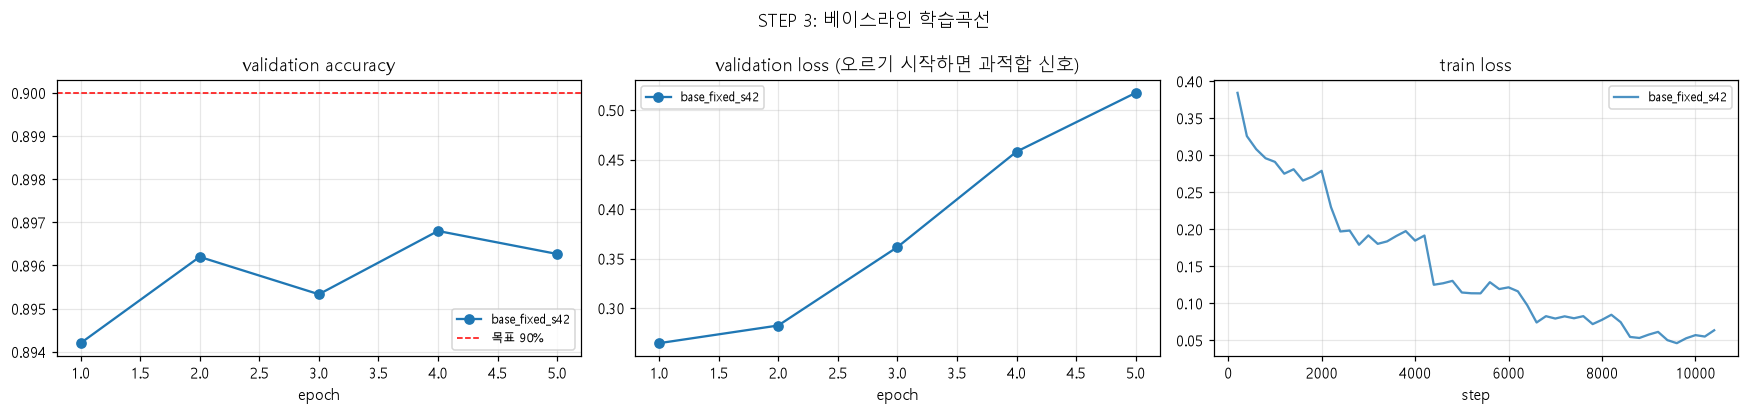

,name,best_epoch,best_val_acc,val_acc_novel,test_acc,test_acc_novel
0,base_fixed_s42,4.0,0.8968,0.8966,0.8969,0.8968


→ 곡선을 보고 8장 STEP 4의 개선 설정(IMPROVED_CFG)을 확정하세요. (1-2 셀에서 수정 가능)


In [17]:
# ===== 7-2. 베이스라인 결과 확인 =====
plot_curves([res_base], "STEP 3: 베이스라인 학습곡선")
display(pd.DataFrame([{k: res_base[k] for k in ["name", "best_epoch", "best_val_acc", "val_acc_novel", "test_acc", "test_acc_novel"]}]).round(4))
print("→ 곡선을 보고 8장 STEP 4의 개선 설정(IMPROVED_CFG)을 확정하세요. (1-2 셀에서 수정 가능)")

## 8. STEP 4 — 전처리·설정 개선으로 validation accuracy 90% 이상 ⏱

베이스라인 결과를 바탕으로 **전처리(결측·중복 제거)** 와 **하이퍼파라미터(`IMPROVED_CFG`: lr 3e-5, warmup 10%)** 를 함께 바꿔 한 번 더 학습합니다. 목표는 validation accuracy 90% 이상입니다.

### 개선 변경점 (베이스라인 → 개선본)

| 번호 | 항목 | 베이스라인 | 개선본 | 기대 효과 |
|---|---|---|---|---|
| **A1** | 결측 `document` | 빈 문자열로 대체 (행 유지) | 행 제거 | 의미 없는 입력 제거 (효과 작음) |
| **A2** | 중복 문장 | 유지 | 첫 행만 남기고 제거 | train↔validation 누수 제거 → 평가 신뢰도↑, 같은 문장 반복 암기↓ |
| **A3** | learning rate | 2e-5 | 3e-5 | 수렴 속도↑ (너무 크면 불안정) |
| **A4** | warmup | 없음 | 전체 스텝의 10% | 학습 초기 불안정 완화 |

**개선본에서도 바뀌지 않는 것**(그래서 개선 효과가 A1~A4에서만 나온다고 볼 수 있음): 모델, 토크나이저, `MAX_LENGTH`(128), 고정 패딩, fp16, 에폭 수, 배치 크기, weight decay, 데이터 분할·`TRAIN_FRACTION`, 평가 방식(최고 에폭 모델).

> **각주 (개선본 기록)**
> ⓐ **A1 결측 제거** — 결측은 train 5건뿐이라 성능 영향은 거의 없고, 의미 없는 입력(빈 문장)을 없애는 위생 처리 성격입니다.
> ⓑ **A2 중복 제거 (가장 큰 변화)** — train에 같은 문장이 수천 건 중복이라, 그대로 두면 validation 문장이 train에도 있어 accuracy가 부풀려집니다. 제거하면 점수가 **오히려 낮아질 수 있으나 그것이 더 정직한 값**입니다(비교용으로 `val_acc_novel`을 함께 기록). 라벨이 충돌하는 문서는 첫 행 라벨이 남는다는 한계가 있습니다.
> ⓒ **A3 학습률** — BERT 논문의 권장 범위(2e-5~5e-5) 안에서 더 큰 값을 골랐습니다. 이 데이터에서 더 좋다는 보장은 없는 **가설**입니다.
> ⓓ **A4 warmup** — 초반에 큰 학습률로 사전학습 가중치가 흔들리는 것을 막는 일반적인 관행입니다(v5: `warmup_steps=0.1`).
> ⓔ **효과 분리 불가** — A1~A4를 한꺼번에 바꿨으므로 어느 항목 덕인지는 이 실험만으로 말할 수 없습니다. 분리하려면 `IMPROVED_CFG = BASE_CFG`로 두고 전처리 효과만 보는 추가 run을 돌리세요.

> **각주**
> ① **개선 효과를 항목별로 나눌 수 없습니다** — 전처리와 하이퍼파라미터를 한꺼번에 바꾸므로, 성능이 올랐을 때 어느 쪽 덕분인지는 이 실험만으로는 말할 수 없습니다. 분리하고 싶다면 `IMPROVED_CFG = BASE_CFG`로 두고 전처리 효과만 따로 보는 추가 run을 돌릴 수 있습니다.
> ② **중복 제거 후 validation accuracy가 오히려 낮아질 수 있습니다** — 베이스라인의 validation에는 train과 같은 문장이 섞여 있어 점수가 부풀려져 있기 때문입니다. 그래서 `val_acc_novel`(겹치지 않는 문장만)과 test 성능을 함께 비교합니다.
> ③ 90%에 못 미치면 곡선을 보고 `IMPROVED_CFG`(lr, warmup, weight_decay)나 `MAX_LENGTH`를 조정해 다시 실행하세요. 설정을 바꾸면 이전 개선본 결과는 자동으로 `_archive`로 옮겨집니다.
> ④ `save_best=True`: 이 run의 최고 모델을 저장해 11장 추론 데모에서 사용합니다(약 440MB).

In [18]:
# ===== 8-1. ⏱ STEP 4: 개선본 학습 (seed = SEEDS[0]) =====
budget_status()
res_impr = run_experiment("impr_fixed", SEEDS[0], save_best=True)

[시간 예산] 완료 1/10 run | 누적 0.6h + 남은 예상(+20% 여유) 5.3h = 5.9h / 예산 7h → ✅ 예산 내


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1562.92it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

▶ impr_fixed_s42 학습 시작 | 전처리=improved 패딩=fixed 샘플링=random seed=42 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.276330,0.268662,0.887407
2,0.201100,0.260767,0.898557
3,0.119282,0.376609,0.895342
4,0.057459,0.476230,0.895957
5,0.036651,0.554869,0.897189


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.17it/s]


✔ impr_fixed_s42: best val acc 0.8986 (epoch 2) | test acc 0.8954 | 에폭당 5.8분 | 총 30.7분


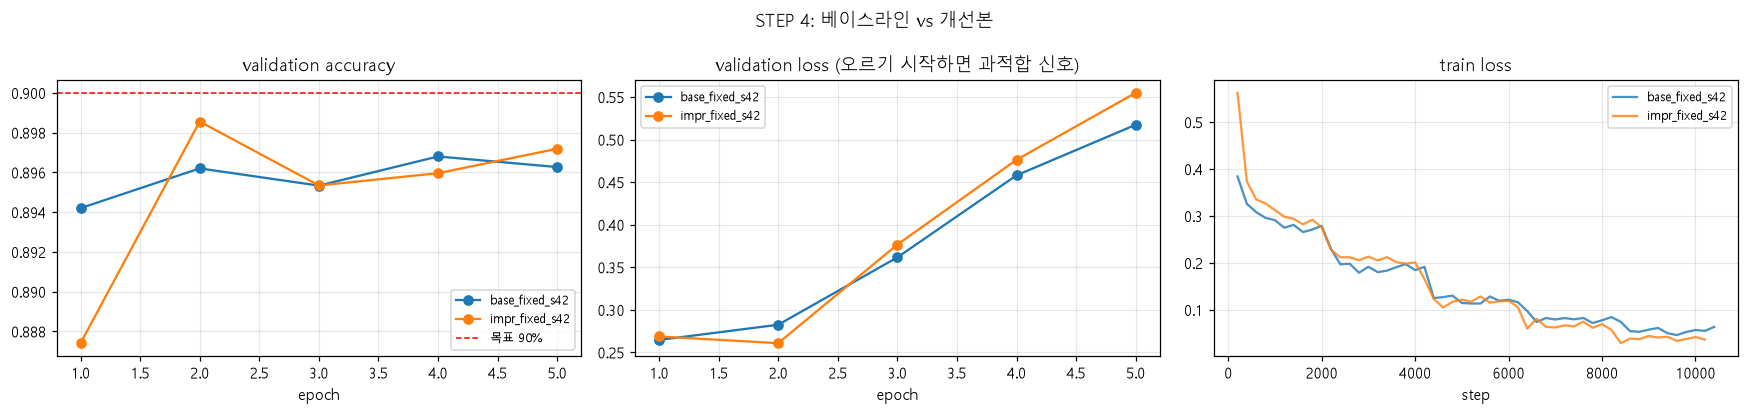

,run,val acc,val acc (train과 안 겹치는 문장만),test acc,test acc (train과 안 겹치는 문장만),best epoch
0,base_fixed_s42,0.8968,0.8966,0.8969,0.8968,4.0
1,impr_fixed_s42,0.8986,0.8986,0.8954,0.8958,2.0


[STEP 4 목표] 개선본 validation accuracy 0.8986 → ❌ 90% 미만 — IMPROVED_CFG/MAX_LENGTH 조정 후 재실행


In [19]:
# ===== 8-2. 베이스라인 vs 개선본 비교 =====
plot_curves([res_base, res_impr], "STEP 4: 베이스라인 vs 개선본")

cmp_cols = {"best_val_acc": "val acc", "val_acc_novel": "val acc (train과 안 겹치는 문장만)",
            "test_acc": "test acc", "test_acc_novel": "test acc (train과 안 겹치는 문장만)",
            "best_epoch": "best epoch"}
cmp = pd.DataFrame([{**{"run": r["name"]}, **{v: r[k] for k, v in cmp_cols.items()}} for r in (res_base, res_impr)])
display(cmp.round(4))

goal = 0.90
print(f"[STEP 4 목표] 개선본 validation accuracy {res_impr['best_val_acc']:.4f} → "
      + ("✅ 90% 이상 달성" if res_impr["best_val_acc"] >= goal else "❌ 90% 미만 — IMPROVED_CFG/MAX_LENGTH 조정 후 재실행"))

**읽는 법 / 리뷰 포인트**
- 개선본의 validation accuracy가 90%를 넘었는지, 그리고 베이스라인 대비 어떻게 달라졌는지 확인합니다.
- 베이스라인의 `val acc`와 `val acc (겹치지 않는 문장만)`의 차이는 **중복 누수로 부풀려진 정도**입니다. 이 차이가 크면 '전처리 개선'의 실질 효과는 겉으로 보이는 validation 점수 변화보다 크다는 뜻입니다.
- validation loss가 오르기 시작하는 에폭이 있으면 그 이후는 과적합 구간이므로, `best epoch`가 5보다 작다면 5에폭이 과했다는 실험적 근거가 됩니다.

## 9. STEP 5 — dynamic padding · bucketing 적용과 비교 ⏱

### 개념
- **Padding 낭비**: 배치의 문장 길이를 맞추려고 `[PAD]`를 채웁니다. 패딩 위치는 `attention_mask`로 가려져 결과에는 영향이 없지만, **연산은 그 위치까지 수행**하므로 GPU 시간이 낭비됩니다. 고정 패딩(128)은 짧은 리뷰가 대부분인 NSMC에서 낭비가 큽니다.
- **Dynamic padding** (`DataCollatorWithPadding`): 토크나이징 때는 패딩하지 않고, 배치를 만들 때 **그 배치에서 가장 긴 문장 길이**로만 패딩합니다.
- **Bucketing** (`train_sampling_strategy="group_by_length"`): **길이가 비슷한 문장끼리 한 배치로 묶어** 배치 안 최대 길이와 각 문장 길이의 차이를 줄입니다. 무작위 배치에서는 긴 문장 하나 때문에 배치 전체가 길어지므로, dynamic padding만 쓸 때보다 패딩이 더 줄어듭니다.

### 비교 설계 — 세 그룹은 '패딩·샘플링 방식'만 다름

| 그룹 | 패딩 | 배치 구성 | 무엇을 보여주나 |
|---|---|---|---|
| `impr_fixed` (STEP 4 개선본) | 항상 128 | 무작위 | 기준선 |
| `impr_dynamic` | 배치 최대 길이 | 무작위 | dynamic padding **만**의 효과 |
| `impr_bucket` | 배치 최대 길이 | 길이별 묶음 | dynamic padding + bucketing의 효과 |

`impr_dynamic → impr_bucket` 차이 = bucketing만의 추가 효과. 각 그룹을 seed 3개(`SEEDS`)로 반복해 평균과 표준편차로 비교합니다.

**STEP 5에서 적용되는 개선(속도 개선, 성능은 유지되는 것이 목표)**: **B1** dynamic padding(배치 최대 길이로만 패딩) · **B2** 길이를 8의 배수로 올림(`PAD_MULTIPLE`, fp16 Tensor Core 정렬) · **B3** bucketing(길이가 비슷한 문장끼리 묶기, `group_by_length`). 코드 주석의 `[개선 B1~B3]` 표시가 해당 위치입니다.

> **각주**
> ① **[중요] 정확도 변화가 생길 수 있는 이유** — 패딩은 마스킹되므로 같은 문장을 넣으면 출력은 사실상 같습니다. 다만 (1) bucketing은 배치가 덜 무작위라 배치마다 그래디언트 성격이 달라질 수 있고, (2) fp16에서는 텐서 크기가 달라 수치 오차가 조금 다르게 쌓입니다. 차이가 나더라도 보통 0.1~0.3%p 수준이라 **seed 변동과 겹칠 수 있어** 반복 실험이 필요합니다.
> ② **Hugging Face의 `group_by_length` 동작** — 데이터를 무작위로 섞은 뒤 `배치 크기 × 최대 50`개짜리 메가배치로 나누고, 각 메가배치 안에서 길이 내림차순으로 정렬해 배치를 만듭니다. 매 에폭 새로 섞이므로 완전한 길이 정렬은 아니고 **무작위성이 일부 유지**됩니다. 따라서 **고정 패딩(`padding="max_length"`)과 함께 쓰면 길이가 모두 같아 효과가 없습니다.**
> ③ **[환경] 시간 절감이 작아 보일 수 있는 이유** — 문장이 짧아지면 GPU가 덜 채워져 스텝당 시간이 비례해서 줄지 않고, `DataCollatorWithPadding`은 배치마다 파이썬에서 패딩 연산을 하므로 오버헤드가 있습니다. 이 오버헤드도 실제 시간에 포함해 비교합니다.
> ④ **[변경 가능]** `PAD_MULTIPLE = 8`이 켜져 있으면 dynamic 배치 길이가 8의 배수로 올림됩니다(fp16 Tensor Core 정렬). 이 값을 1로 바꿔 시간 차이를 비교해 볼 수도 있습니다.
> ⑤ 평가(validation) sampler에도 `group_by_length`가 적용되지만 순서만 바뀔 뿐 accuracy 값에는 영향이 없습니다(최종 예측은 6장 각주 ③처럼 순서 고정 방식으로 별도 계산).

{'fixed': '82.2%', 'dynamic': '70.7%', 'bucketing': '17.4%'} ← 패딩 비율(시뮬레이션)


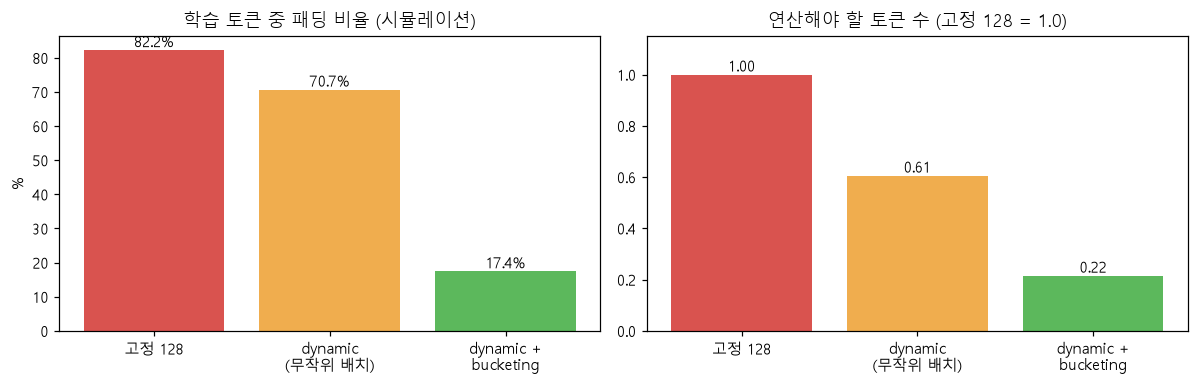

In [20]:
# ===== 9-1. 패딩 낭비 시뮬레이션 (학습 전, 실제 토큰 길이 기반) =====
_dyn_train = _BUNDLES[("improved", "dynamic")]["train"]
lens_train = np.array([len(x) for x in _dyn_train["input_ids"]])          # 잘림 적용 후 실제 길이

def simulate_pad_ratio(lengths, batch_size, mode, pad_multiple=1, max_len=MAX_LENGTH, seed=0):
    """mode='fixed'|'dynamic'|'bucketing' 일 때 학습 토큰 중 패딩 비율(0~1)을 근사 계산.
       bucketing은 HF LengthGroupedSampler와 같은 방식(메가배치 = 배치×최대 50, 내림차순 정렬)을 재현."""
    lengths = np.minimum(np.asarray(lengths), max_len)
    n = len(lengths)
    if mode == "fixed":
        return 1 - lengths.sum() / (n * max_len)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    if mode == "bucketing":
        mega = max(1, min(n // (batch_size * 4), 50)) * batch_size
        idx = np.concatenate([sorted(idx[i:i + mega], key=lambda j: -lengths[j]) for i in range(0, n, mega)])
    padded = real = 0
    for i in range(0, n, batch_size):
        b = lengths[idx[i:i + batch_size]]
        L = int(np.ceil(b.max() / pad_multiple) * pad_multiple)
        padded += L * len(b); real += b.sum()
    return 1 - real / padded

_pm = PAD_MULTIPLE if FP16 else 1
sim = {m: simulate_pad_ratio(lens_train, TRAIN_BS, m, pad_multiple=_pm) for m in ["fixed", "dynamic", "bucketing"]}
rel_cost = {m: (1 - sim[m]) ** -1 * (1 - sim["fixed"]) for m in sim}     # 패딩 포함 토큰 수(연산량 근사) — 고정 대비 상대값
print({k: f"{v:.1%}" for k, v in sim.items()}, "← 패딩 비율(시뮬레이션)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
names = ["고정 128", "dynamic\n(무작위 배치)", "dynamic +\nbucketing"]
axes[0].bar(names, [sim[m] * 100 for m in ["fixed", "dynamic", "bucketing"]], color=["#d9534f", "#f0ad4e", "#5cb85c"])
for i, m in enumerate(["fixed", "dynamic", "bucketing"]): axes[0].text(i, sim[m] * 100, f"{sim[m]:.1%}", ha="center", va="bottom")
axes[0].set_title("학습 토큰 중 패딩 비율 (시뮬레이션)"); axes[0].set_ylabel("%")
axes[1].bar(names, [rel_cost[m] for m in ["fixed", "dynamic", "bucketing"]], color=["#d9534f", "#f0ad4e", "#5cb85c"])
for i, m in enumerate(["fixed", "dynamic", "bucketing"]): axes[1].text(i, rel_cost[m], f"{rel_cost[m]:.2f}", ha="center", va="bottom")
axes[1].set_title("연산해야 할 토큰 수 (고정 128 = 1.0)"); axes[1].set_ylim(0, 1.15)
plt.tight_layout(); plt.show()

**읽는 법 / 리뷰 포인트**
- 오른쪽 그래프의 값이 작을수록 **연산량이 적다**는 뜻입니다. 이 값이 실제 학습 시간이 줄어드는 비율의 **상한선 근처의 참고값**입니다(실제로는 9장 각주 ③의 오버헤드 때문에 이만큼 줄지는 않습니다).
- 학습이 끝난 뒤 실제로 측정한 패딩 비율(`pad_ratio`)이 이 시뮬레이션과 비슷한지 10장에서 비교합니다.

> **각주** 시뮬레이션은 한 에폭 분량을 한 번 섞어서 계산한 근사값이며, 실제 학습에서는 에폭마다 다시 섞이므로 값이 조금씩 달라집니다.

In [21]:
# ===== 9-2. ⏱ STEP 5 준비: 개선본 추가 seed (기준선 3회 완성) =====
budget_status()
res_impr_all = [res_impr] + [run_experiment("impr_fixed", s) for s in SEEDS[1:]]

[시간 예산] 완료 2/10 run | 누적 1.1h + 남은 예상(+20% 여유) 4.4h = 5.5h / 예산 7h → ✅ 예산 내


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24873.84it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

▶ impr_fixed_s43 학습 시작 | 전처리=improved 패딩=fixed 샘플링=random seed=43 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.284074,0.273496,0.886107
2,0.218466,0.283539,0.895752
3,0.122679,0.342028,0.896847
4,0.062786,0.478008,0.896573
5,0.039229,0.556428,0.895889


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.85it/s]


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7504.91it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

▶ impr_fixed_s44 학습 시작 | 전처리=improved 패딩=fixed 샘플링=random seed=44 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.286903,0.266686,0.891237
2,0.204267,0.266732,0.897804
3,0.122238,0.370279,0.901566
4,0.077897,0.466354,0.897189
5,0.030093,0.574340,0.896368


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


✔ impr_fixed_s44: best val acc 0.9016 (epoch 3) | test acc 0.8972 | 에폭당 5.7분 | 총 30.2분


In [22]:
# ===== 9-3. ⏱ STEP 5: dynamic padding만 적용 (seed 3회) =====
budget_status()
res_dyn_all = [run_experiment("impr_dynamic", s) for s in SEEDS]

[시간 예산] 완료 4/10 run | 누적 2.2h + 남은 예상(+20% 여유) 3.1h = 5.3h / 예산 7h → ✅ 예산 내


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18938.27it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

▶ impr_dynamic_s42 학습 시작 | 전처리=improved 패딩=dynamic 샘플링=random seed=42 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.273918,0.264105,0.892195
2,0.199015,0.249445,0.899925
3,0.124794,0.331371,0.896231
4,0.068173,0.469230,0.896641
5,0.039766,0.534794,0.900198


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.20it/s]


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6520.63it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

▶ impr_dynamic_s44 학습 시작 | 전처리=improved 패딩=dynamic 샘플링=random seed=44 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.287581,0.255932,0.893290
2,0.209388,0.275977,0.895136
3,0.123149,0.348187,0.899925
4,0.075633,0.460570,0.897189
5,0.036520,0.557382,0.897804


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.23it/s]


✔ impr_dynamic_s44: best val acc 0.8999 (epoch 3) | test acc 0.8946 | 에폭당 4.3분 | 총 23.0분


In [23]:
# ===== 9-4. ⏱ STEP 5: dynamic padding + bucketing 적용 (seed 3회) =====
budget_status()
res_bkt_all = [run_experiment("impr_bucket", s) for s in SEEDS]

[시간 예산] 완료 7/10 run | 누적 3.4h + 남은 예상(+20% 여유) 1.3h = 4.7h / 예산 7h → ✅ 예산 내


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1679.37it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

▶ impr_bucket_s42 학습 시작 | 전처리=improved 패딩=dynamic 샘플링=bucketing seed=42 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.273851,0.265821,0.886586
2,0.205676,0.263876,0.899378
3,0.121218,0.339139,0.898009
4,0.068440,0.454845,0.896094
5,0.036763,0.541946,0.898215


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.12it/s]


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23369.54it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

▶ impr_bucket_s44 학습 시작 | 전처리=improved 패딩=dynamic 샘플링=bucketing seed=44 cfg={'learning_rate': 3e-05, 'warmup_steps': 0.1, 'weight_decay': 0.01} | train 65,781 / val 14,619


Epoch,Training Loss,Validation Loss,Accuracy
1,0.278254,0.256368,0.893358
2,0.199660,0.263183,0.897257
3,0.111139,0.358496,0.895615
4,0.062811,0.446183,0.897189
5,0.041448,0.571774,0.896368


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.02it/s]


✔ impr_bucket_s44: best val acc 0.8973 (epoch 2) | test acc 0.8934 | 에폭당 3.3분 | 총 16.8분


## 10. 결과 비교 — 성능과 학습 시간

저장된 모든 run(`summary.json`)을 모아 그룹별 **평균 ± 표준편차**로 비교합니다. 세 가지를 봅니다.

1. **성능**: validation accuracy(최고 에폭), test accuracy
2. **속도**: 에폭당 순수 학습 시간, 총 학습 시간, 실제 패딩 비율
3. **trade-off**: 시간을 줄였을 때 성능이 함께 변하는가?

> **각주**
> ① 베이스라인은 run이 1개라 표준편차가 없습니다(`NaN`).
> ② 시간 값은 이어서 학습한 run(`resumed=True`)을 제외하고 평균냅니다.
> ③ **표준편차는 seed가 3개뿐이라 매우 불안정한 추정치**입니다(n=3). 그래서 검정 통계량 대신 '평균 차이가 표준편차보다 큰가'와 '개별 seed 점수의 범위가 겹치는가'를 참고 기준으로 씁니다. 엄밀한 통계적 유의성 주장은 하지 않습니다.

In [24]:
# ===== 10-1. 모든 run 결과 모아 표로 =====
def to_frame(rows):
    df = pd.DataFrame([{
        "group": r["group"], "seed": r["seed"], "best_epoch": r["best_epoch"],
        "val_acc": r["best_val_acc"], "val_acc_novel": r["val_acc_novel"],
        "test_acc": r["test_acc"], "test_acc_novel": r["test_acc_novel"],
        "epoch_min": (np.mean(r["epoch_train_sec"]) / 60) if not r["resumed"] else np.nan,
        "total_min": (r["total_train_sec"] / 60) if not r["resumed"] else np.nan,
        "pad_ratio": r["pad_ratio"] if not r["resumed"] else np.nan,
        "peak_mem_gb": r["peak_mem_gb"],
    } for r in rows])
    for c in df.columns.drop("group"):
        df[c] = pd.to_numeric(df[c], errors="coerce")          # None → NaN (평균·표준편차 계산용)
    df["group"] = pd.Categorical(df["group"], categories=list(GROUPS), ordered=True)
    return df.sort_values(["group", "seed"]).reset_index(drop=True)

runs = to_frame(collect_results())
print("run 목록 (개별 결과)")
display(runs.round(4))

agg = runs.groupby("group", observed=True).agg(["mean", "std"]).drop(columns=["seed"], level=0)
agg.columns = [f"{a}_{b}" for a, b in agg.columns]
agg.insert(0, "n_runs", runs.groupby("group", observed=True).size())
print("\n그룹별 평균 / 표준편차")
display(agg.round(4))
agg.to_csv(RESULTS_DIR / "results_table.csv", encoding="utf-8-sig")       # 엑셀에서 한글이 안 깨지도록 utf-8-sig

run 목록 (개별 결과)


,group,seed,best_epoch,val_acc,val_acc_novel,test_acc,test_acc_novel,epoch_min,total_min,pad_ratio,peak_mem_gb
0,base_fixed,42,4.0,0.8968,0.8966,0.8969,0.8968,6.4082,33.8263,0.8253,3.0205
1,impr_fixed,42,2.0,0.8986,0.8986,0.8954,0.8958,5.8094,30.6585,0.8224,3.0205
2,impr_fixed,43,3.0,0.8968,0.8968,0.8935,0.8938,5.7224,30.1975,0.8224,3.0205
3,impr_fixed,44,3.0,0.9016,0.9016,0.8972,0.8974,5.7180,30.1818,0.8224,3.0205
4,impr_dynamic,42,5.0,0.9002,0.9002,0.8948,0.8952,4.2014,22.2004,0.7062,3.0193
5,impr_dynamic,43,4.0,0.8990,0.8990,0.8962,0.8963,4.3132,22.8271,0.7062,3.0317
6,impr_dynamic,44,3.0,0.8999,0.8999,0.8946,0.8948,4.3426,22.9734,0.7064,3.0293
7,impr_bucket,42,2.0,0.8994,0.8994,0.8966,0.8974,3.2565,16.8165,0.1742,3.0190
8,impr_bucket,43,5.0,0.8974,0.8974,0.8956,0.8959,3.2572,16.8139,0.1735,3.0249
9,impr_bucket,44,2.0,0.8973,0.8973,0.8934,0.8938,3.2541,16.8011,0.1733,3.0200



그룹별 평균 / 표준편차


,n_runs,best_epoch_mean,best_epoch_std,val_acc_mean,val_acc_std,val_acc_novel_mean,val_acc_novel_std,test_acc_mean,test_acc_std,test_acc_novel_mean,test_acc_novel_std,epoch_min_mean,epoch_min_std,total_min_mean,total_min_std,pad_ratio_mean,pad_ratio_std,peak_mem_gb_mean,peak_mem_gb_std
group,,,,,,,,,,,,,,,,,,,
base_fixed,1,4.0000,NaN,0.8968,NaN,0.8966,NaN,0.8969,NaN,0.8968,NaN,6.4082,NaN,33.8263,NaN,0.8253,NaN,3.0205,NaN
impr_fixed,3,2.6667,0.5774,0.8990,0.0024,0.8990,0.0024,0.8953,0.0019,0.8957,0.0018,5.7499,0.0516,30.3459,0.2708,0.8224,0.0000,3.0205,0.0000
impr_dynamic,3,4.0000,1.0000,0.8997,0.0006,0.8997,0.0006,0.8952,0.0009,0.8955,0.0008,4.2857,0.0745,22.6669,0.4106,0.7062,0.0001,3.0268,0.0066
impr_bucket,3,3.0000,1.7321,0.8980,0.0012,0.8980,0.0012,0.8952,0.0017,0.8957,0.0018,3.2559,0.0016,16.8105,0.0083,0.1737,0.0004,3.0213,0.0031


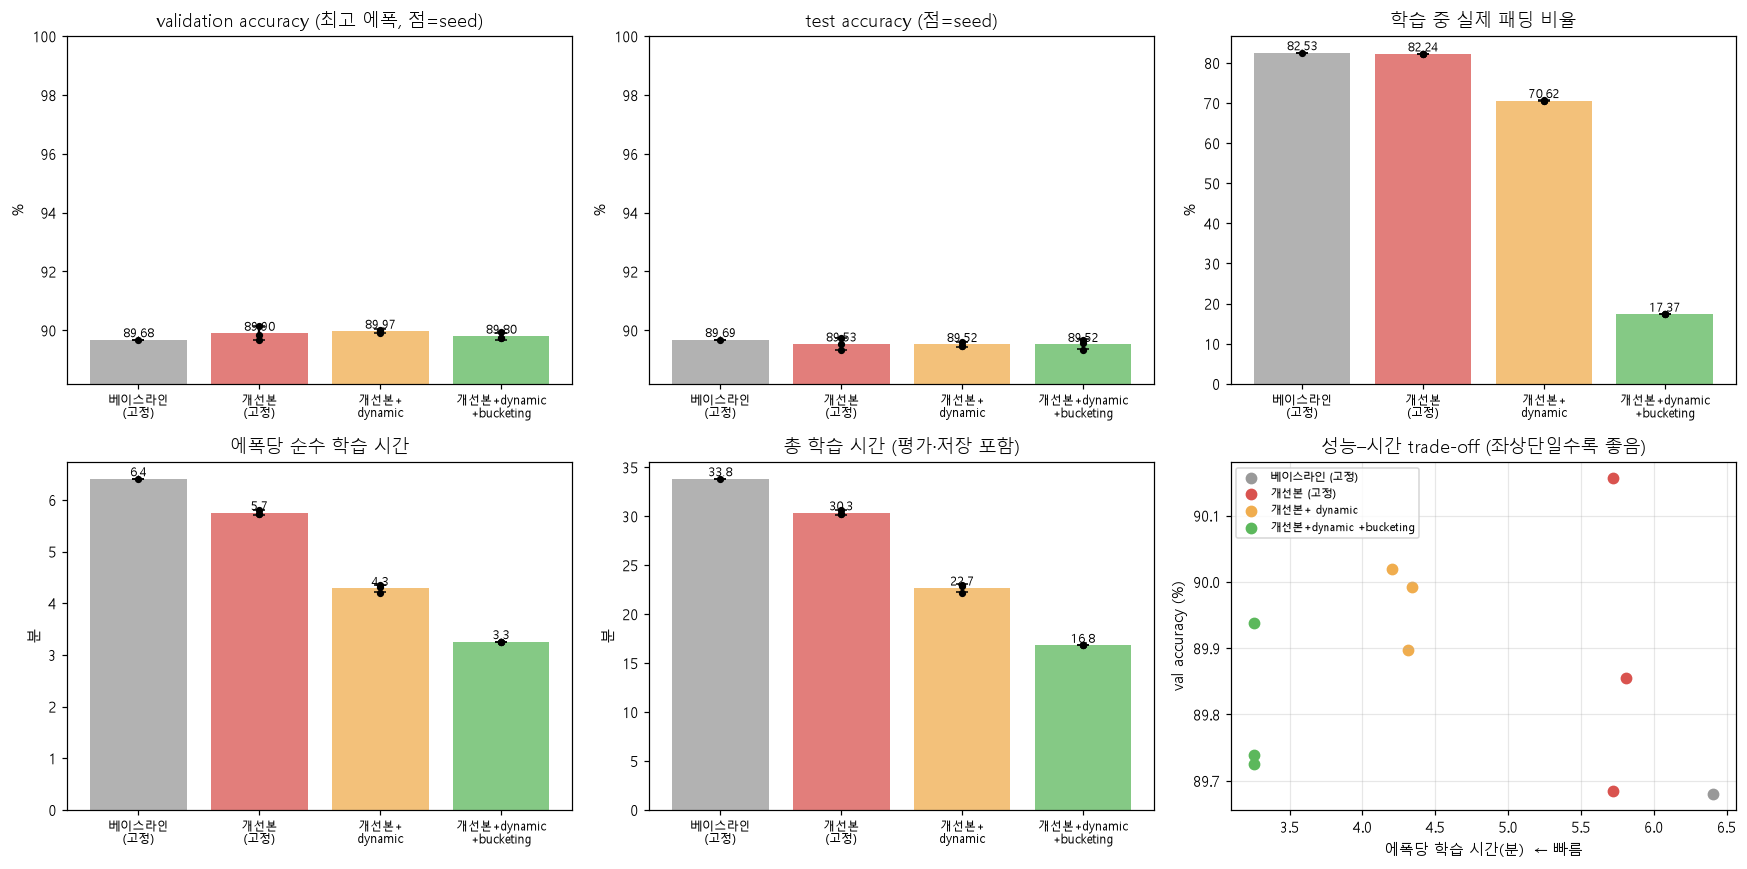

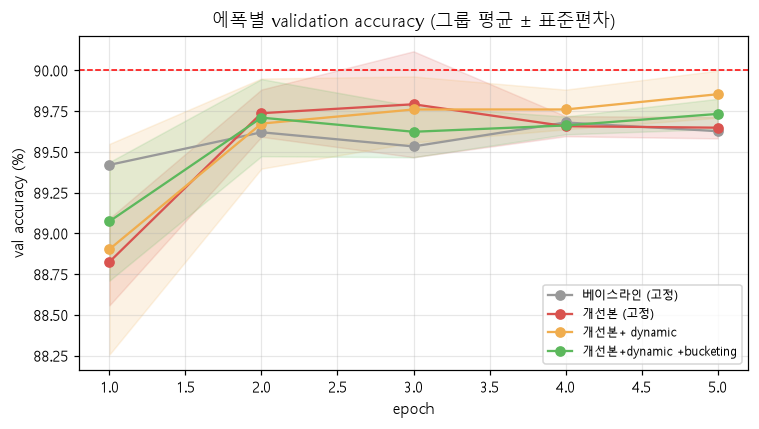

In [25]:
# ===== 10-2. 비교 시각화 =====
order = [g for g in GROUPS if g in set(runs["group"])]
short = {"base_fixed": "베이스라인\n(고정)", "impr_fixed": "개선본\n(고정)",
         "impr_dynamic": "개선본+\ndynamic", "impr_bucket": "개선본+dynamic\n+bucketing"}
colors = {"base_fixed": "#999999", "impr_fixed": "#d9534f", "impr_dynamic": "#f0ad4e", "impr_bucket": "#5cb85c"}

def bar_with_points(ax, col, title, ylabel, pct=False, ylim=None):
    for i, g in enumerate(order):
        vals = runs.loc[runs["group"] == g, col].dropna().to_numpy()
        if len(vals) == 0: continue
        scale = 100 if pct else 1
        m, s = vals.mean() * scale, (vals.std(ddof=1) * scale if len(vals) > 1 else 0)
        ax.bar(i, m, yerr=s, capsize=4, color=colors[g], alpha=0.75)
        ax.scatter([i] * len(vals), vals * scale, color="black", s=14, zorder=3)     # 개별 seed 점수
        ax.text(i, m, f"{m:.2f}" if pct else f"{m:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([short[g] for g in order], fontsize=8)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
lo = max(0, runs["val_acc"].min() * 100 - 1.5) if len(runs) else 0
bar_with_points(axes[0, 0], "val_acc", "validation accuracy (최고 에폭, 점=seed)", "%", pct=True, ylim=(lo, 100))
bar_with_points(axes[0, 1], "test_acc", "test accuracy (점=seed)", "%", pct=True, ylim=(lo, 100))
bar_with_points(axes[0, 2], "pad_ratio", "학습 중 실제 패딩 비율", "%", pct=True)
bar_with_points(axes[1, 0], "epoch_min", "에폭당 순수 학습 시간", "분")
bar_with_points(axes[1, 1], "total_min", "총 학습 시간 (평가·저장 포함)", "분")
# trade-off 산점도: x=에폭당 시간, y=validation accuracy
ax = axes[1, 2]
for g in order:
    d = runs[runs["group"] == g].dropna(subset=["epoch_min"])
    ax.scatter(d["epoch_min"], d["val_acc"] * 100, color=colors[g], s=45, label=short[g].replace("\n", " "))
ax.set_xlabel("에폭당 학습 시간(분)  ← 빠름"); ax.set_ylabel("val accuracy (%)"); ax.legend(fontsize=7)
ax.set_title("성능–시간 trade-off (좌상단일수록 좋음)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 에폭별 validation accuracy 곡선 (그룹 평균)
fig, ax = plt.subplots(figsize=(7, 4))
for g in order:
    curves = [[x["eval_accuracy"] for x in r["val_curve"]] for r in collect_results() if r["group"] == g]
    L = min(len(c) for c in curves); arr = np.array([c[:L] for c in curves]) * 100
    ax.plot(range(1, L + 1), arr.mean(0), marker="o", color=colors[g], label=short[g].replace("\n", " "))
    if len(arr) > 1: ax.fill_between(range(1, L + 1), arr.mean(0) - arr.std(0, ddof=1), arr.mean(0) + arr.std(0, ddof=1), color=colors[g], alpha=0.15)
ax.axhline(90, color="red", ls="--", lw=1); ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy (%)")
ax.set_title("에폭별 validation accuracy (그룹 평균 ± 표준편차)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [26]:
# ===== 10-3. 자동 요약 (수치로 확인하는 핵심 비교) =====
def mean_std(g, col):
    v = runs.loc[runs["group"] == g, col].dropna().to_numpy()
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else np.nan, len(v)) if len(v) else (np.nan, np.nan, 0)

def compare(a, b, label):
    (va, sa, na), (vb, sb, nb) = mean_std(a, "val_acc"), mean_std(b, "val_acc")
    (ta, _, _), (tb, _, _) = mean_std(a, "epoch_min"), mean_std(b, "epoch_min")
    (pa, _, _), (pb, _, _) = mean_std(a, "pad_ratio"), mean_std(b, "pad_ratio")
    if np.isnan(va) or np.isnan(vb):
        print(f"[{label}] 아직 결과가 없어 건너뜀"); return
    d = (vb - va) * 100
    sd = np.nanmax([sa, sb]) * 100
    print(f"[{label}]")
    print(f"  · 속도  : 에폭당 {ta:.2f}분 → {tb:.2f}분  ({ta/tb:.2f}배 빠름) | 패딩 비율 {pa:.1%} → {pb:.1%}")
    print(f"  · 성능  : val acc {va*100:.2f}% → {vb*100:.2f}%  (차이 {d:+.2f}%p, seed 표준편차 최대 {sd:.2f}%p)")
    if np.isnan(sd):
        print("  · 판단  : seed가 1개라 변동 폭을 알 수 없음")
    elif abs(d) <= sd:
        print("  · 판단  : 차이가 seed 변동 범위 이내 → 성능 변화가 있다고 말하기 어려움 (속도 이득만 확인)")
    else:
        print("  · 판단  : 차이가 seed 변동보다 큼 → 성능 변화 가능성 (다만 n=3이라 잠정적)")

compare("impr_fixed", "impr_dynamic", "개선본(고정) → dynamic padding")
compare("impr_dynamic", "impr_bucket", "dynamic → dynamic + bucketing (bucketing의 추가 효과)")
compare("impr_fixed", "impr_bucket", "개선본(고정) → dynamic + bucketing (전체 효과)")

v90 = [(g, mean_std(g, "val_acc")[0]) for g in order]
print("\n[90% 목표 점검]", " | ".join(f"{g}: {v*100:.2f}% {'✅' if v >= 0.9 else '❌'}" for g, v in v90))

[개선본(고정) → dynamic padding]
  · 속도  : 에폭당 5.75분 → 4.29분  (1.34배 빠름) | 패딩 비율 82.2% → 70.6%
  · 성능  : val acc 89.90% → 89.97%  (차이 +0.07%p, seed 표준편차 최대 0.24%p)
  · 판단  : 차이가 seed 변동 범위 이내 → 성능 변화가 있다고 말하기 어려움 (속도 이득만 확인)
[dynamic → dynamic + bucketing (bucketing의 추가 효과)]
  · 속도  : 에폭당 4.29분 → 3.26분  (1.32배 빠름) | 패딩 비율 70.6% → 17.4%
  · 성능  : val acc 89.97% → 89.80%  (차이 -0.17%p, seed 표준편차 최대 0.12%p)
  · 판단  : 차이가 seed 변동보다 큼 → 성능 변화 가능성 (다만 n=3이라 잠정적)
[개선본(고정) → dynamic + bucketing (전체 효과)]
  · 속도  : 에폭당 5.75분 → 3.26분  (1.77배 빠름) | 패딩 비율 82.2% → 17.4%
  · 성능  : val acc 89.90% → 89.80%  (차이 -0.10%p, seed 표준편차 최대 0.24%p)
  · 판단  : 차이가 seed 변동 범위 이내 → 성능 변화가 있다고 말하기 어려움 (속도 이득만 확인)

[90% 목표 점검] base_fixed: 89.68% ❌ | impr_fixed: 89.90% ❌ | impr_dynamic: 89.97% ❌ | impr_bucket: 89.80% ❌


### 결과 분석

> 수치는 10-1·10-3 출력의 그룹 평균입니다. `±`는 seed 3개의 표준편차이고, 베이스라인은 1회라 표준편차가 없습니다.

| 그룹 | val acc | test acc | 최고 에폭(평균) | 에폭당 학습 시간 | 실제 패딩 비율 |
|---|---|---|---|---|---|
| 베이스라인 (고정 패딩) | 89.68% (1회) | 89.69% | 4 | 6.41분 | 82.5% |
| 개선본 (고정 패딩) | 89.90% ± 0.24 | 89.53% ± 0.19 | 2.7 | 5.75분 | 82.2% |
| 개선본 + dynamic padding | 89.97% ± 0.06 | 89.52% ± 0.09 | 4.0 | 4.29분 | 70.6% |
| 개선본 + dynamic + bucketing | 89.80% ± 0.12 | 89.52% ± 0.17 | 3.0 | 3.26분 | 17.4% |

개별 run의 val acc: 개선본(고정) 89.86 / 89.68 / **90.16**, dynamic **90.02** / 89.90 / 89.99, bucketing 89.94 / 89.74 / 89.73 (seed 42 / 43 / 44 순, 굵은 글씨가 90% 이상).

**1. 전처리·설정 개선 (STEP 4)**
- **결과**: validation accuracy는 베이스라인 89.68% → 개선본 89.90%로 **+0.22%p** 올랐지만, test accuracy는 89.69% → 89.53%로 **−0.16%p** 내려갔습니다(겹치지 않는 문장만의 test는 89.68% → 89.57%, −0.11%p). 두 지표의 방향이 반대이고 둘 다 개선본 seed 표준편차(val 0.24%p, test 0.19%p) 이내이며 베이스라인은 1회뿐이므로, **개선 효과가 있었다고 결론 내릴 수 없습니다.**
- **중복 제거(누수)의 영향**: 베이스라인의 val acc 89.68%와 train과 겹치지 않는 문장만의 val acc 89.66%의 차이는 **0.02%p**로, 중복이 validation 점수를 부풀린 정도는 무시할 수준이었습니다. 따라서 A2(중복 제거)는 점수를 바꾸는 개선이라기보다 평가의 정당성을 확보하는 위생 처리로 보는 것이 맞습니다(베이스라인 1회 기준).
- **train–test 겹침의 영향**: 전체 test acc와 겹치지 않는 문장만의 test acc 차이는 −0.01~+0.05%p로 미미했습니다.
- **90% 목표**: **그룹 평균은 네 그룹 모두 90%에 미달**했습니다(89.68~89.97%). 개별 run 중에는 개선본(고정) seed 44가 90.16%, dynamic seed 42가 90.02%로 넘었습니다. 다만 (1) 최고 에폭을 validation으로 골랐기 때문에 이 값은 다소 낙관적이고, (2) 체크포인트 선택에 쓰이지 않은 test는 89.5% 안팎으로 validation보다 약 0.4%p 낮으며, (3) 넘은 run이 seed 변동과 겹치는 범위 안에 있으므로, **"90% 경계선 부근에서 seed에 따라 넘나든다"** 가 정확한 표현입니다. val과 test의 격차가 선택 편향 때문인지 분포 차이 때문인지는 이 실험으로 분리하지 못했습니다.
- **에폭·과적합**: 확인한 학습곡선 두 개(개선본 seed 42, 베이스라인 seed 42) 기준으로, 개선본 seed 42는 validation loss가 3에폭부터 크게 올랐고 accuracy 최고점은 2에폭이었습니다. 베이스라인 seed 42는 2에폭에서 loss가 조금 올랐고 3에폭부터 기울기가 커졌지만 accuracy 최고점은 4에폭이었습니다. loss는 올라도 accuracy는 유지되는 구간이 있는데, 이는 예측 확신이 커지는 과신 때문일 수 있고(추정) 곧바로 accuracy 하락을 뜻하지는 않습니다. 최고 에폭이 seed마다 2~5로 갈렸으므로 에폭 간 accuracy 차이는 노이즈 수준이며, **5에폭은 필요 이상이었고 2~3에폭에서 대부분 도달**했다고 판단합니다(나머지 run의 곡선은 확인하지 않았습니다).

**2. 속도 (STEP 5)**
- **dynamic padding**: 에폭당 5.75분 → 4.29분(**1.34배**), 패딩 비율 82.2% → 70.6%.
- **bucketing 추가**: 4.29분 → 3.26분(**1.32배**), 패딩 비율 70.6% → 17.4%. 고정 패딩 대비 전체 **1.77배**.
- **평균 길이**: 실측 패딩 비율로 계산하면 학습 문장의 실제 평균 길이는 약 23토큰이고, 배치 평균 길이는 고정 128 → dynamic 약 77 → bucketing 약 28토큰입니다.
- **시뮬레이션과의 비교**: 9-1 시뮬레이션의 패딩 비율(82.2% / 70.7% / 17.4%)은 실측(82.2% / 70.6% / 17.4%)과 **0.1%p 이내로 일치**했습니다. 배치 구성이 예상대로 동작했다는 뜻이며, 아래의 시간 절감 한계는 패딩 예측이 아니라 다른 요인 때문입니다.
- **처리 토큰 수 대비 시간 절감이 작은 이유**: 처리 토큰은 dynamic에서 약 1.65배, bucketing에서 약 4.6배 줄었지만 시간은 1.34배, 1.77배만 줄었습니다. 가능한 이유는 (a) 문장이 짧아지면 GPU를 덜 채워 스텝당 시간이 토큰 수에 비례해 줄지 않고, (b) 옵티마이저 갱신·파이썬 데이터 처리 같은 스텝당 고정 오버헤드가 있으며, (c) `DataCollatorWithPadding`이 배치마다 패딩 연산을 하기 때문입니다. **이 세 가지는 직접 검증하지 않은 추정입니다.**
- **시간 측정의 주의점**: 베이스라인은 개선본(고정)과 패딩·배치가 같은데도 에폭당 6.41분으로 약 11% 느렸습니다. 학습 데이터가 약 2.6% 더 많은 것을 감안해도 설명되지 않는 차이로, 첫 run이라는 점 등 실행 환경 요인으로 추정되지만 확인하지는 못했습니다. 그래서 속도 비교는 개선본 그룹 세 개(모두 seed 3회 평균, 시간 표준편차 0.002~0.075분)만 사용했습니다.

**3. 성능–시간 trade-off**

| 비교 | 속도 | val acc 차이 | test acc 차이 | seed 표준편차(val, 최대) | 판단 |
|---|---|---|---|---|---|
| 고정 → dynamic | 1.34배 | +0.07%p | −0.01%p | 0.24%p | 성능 변화 근거 없음 |
| dynamic → +bucketing | 1.32배 | −0.17%p | 0.00%p | 0.12%p | val은 변동보다 크지만 test는 차이 없음 |
| 고정 → +bucketing (전체) | 1.77배 | −0.10%p | −0.01%p | 0.24%p | 성능 변화 근거 없음 |

- **결론**: dynamic padding은 정확도 변화 없이 학습을 1.34배, bucketing까지 적용하면 **1.77배 빠르게** 했습니다. 정확도는 test에서 세 그룹이 89.52~89.53%로 사실상 같았습니다. validation에서는 dynamic 대비 bucketing이 −0.17%p로 seed 표준편차(0.12%p)보다 컸지만, 개별 run의 범위가 겹치고(bucketing 최고 89.94% vs dynamic 최저 89.90%) test에서는 차이가 없었으므로 **"bucketing으로 정확도 손실이 있다"고 말할 근거는 부족합니다.**
- **해상도 한계**: validation이 약 1.46만 건이라 accuracy 하나의 표준오차만 약 0.25%p(정확도 90% 가정 시 계산값)입니다. 세 그룹의 차이(0.07~0.17%p)는 이 해상도 이하입니다.

**4. 한계**
- **seed 3회(n=3)**: 표준편차가 불안정해서 "변동 범위 이내"라는 판단이 거칠고, 베이스라인은 1회라 개선 효과를 검정할 수 없습니다.
- **개선 항목 미분리**: A1~A4를 한꺼번에 바꿔서 어느 항목의 효과인지 알 수 없습니다.
- **학습 데이터 절반 사용**: 시간 예산(7시간) 때문에 `TRAIN_FRACTION = 0.5`로 학습했고, 이것이 90% 경계선 성능의 원인일 수 있으나 이 실험으로 검증하지는 못했습니다.
- **에폭 수**: 5에폭은 필요 이상이었을 가능성이 큽니다(1장 참조).
- **환경**: 시간은 RTX 4060, fp16, `PAD_MULTIPLE = 8` 조건의 측정값입니다. 전체 학습 시간의 합은 약 4.1시간으로, 6-3 프리플라이트 예상(약 5.05시간)보다 짧았습니다.

**5. 추가 시도 기록**
- [입력: 시도한 내용과 결과]

## 11. 추론 데모 (선택)

STEP 4 개선본(`impr_fixed`, `SEEDS[0]`)의 최고 모델로 임의의 문장을 분류해 봅니다.

> **각주** `save_best=True`로 저장한 모델이 있을 때만 동작합니다(디버그 모드에서는 저장 위치가 `results_debug/`).

In [27]:
# ===== 11-1. 추론 데모 =====
from transformers import pipeline

best_dir = RESULTS_DIR / f"impr_fixed_s{SEEDS[0]}" / "best_model"
if best_dir.exists():
    clf = pipeline("text-classification", model=str(best_dir), tokenizer=str(best_dir),
                   device=0 if USE_CUDA else -1)
    for s in ["연기도 스토리도 다 좋았어요. 강추합니다!", "시간 낭비였다... 돈이 아깝다", "그냥 보통이었음"]:
        print(f"{s}  →  {clf(s)[0]}")
else:
    print("저장된 best_model이 없습니다. (8장에서 save_best=True로 학습해야 합니다)")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1782.77it/s]


연기도 스토리도 다 좋았어요. 강추합니다!  →  {'label': '긍정', 'score': 0.9943311214447021}
시간 낭비였다... 돈이 아깝다  →  {'label': '부정', 'score': 0.9984190464019775}
그냥 보통이었음  →  {'label': '부정', 'score': 0.9714450836181641}


## 12. 마무리

### 평가 항목 점검표

| 평가 항목 | 확인 위치 |
|---|---|
| 모델과 데이터를 정상적으로 불러오고 작동 확인 | 2장(두 방식 로드·비교), 4-2(모델 forward 확인) |
| klue/bert-base를 NSMC로 fine-tuning, 정상 작동 | 7장(베이스라인 학습·곡선) |
| Preprocessing 개선 + fine-tuning으로 성능 개선 | 5장(전처리 정책·누수 점검), 8장(개선본 비교) |
| Validation accuracy 90% 이상 | 8-2 (목표 점검 출력), 10-3 (그룹별 점검) |
| Bucketing 적용 + 결과 비교분석 | 9장(설계·시뮬레이션·학습), 10장(표·그래프·자동 요약) |
| 연산 속도–성능 trade-off 확인·분석 | 10-2(산점도), 10-3, 결과 분석 |

### 개선 내역 총정리 (각주)

| 번호 | 개선 내용 | 적용 범위 | 코드 위치 (주석 `[개선 ○]` 검색) | 성능/속도 영향 |
|---|---|---|---|---|
| A1 | 결측 행 제거 | 개선본 이후 | 5-1 `clean_train` | 성능 영향 거의 없음 |
| A2 | 중복 문장 제거 | 개선본 이후 | 5-1 `clean_train` | validation 신뢰도↑ (점수는 낮아질 수 있음) |
| A3 | learning rate 2e-5 → 3e-5 | 개선본 이후 | 1-2 `IMPROVED_CFG`, 6-1 `TrainingArguments` | 성능(가설) |
| A4 | warmup 없음 → 10% | 개선본 이후 | 1-2 `IMPROVED_CFG`, 6-1 `TrainingArguments` | 성능(가설) |
| B1 | dynamic padding | STEP 5 | 6-1 `DataCollatorWithPadding` | 속도↑, 성능 유지 목표 |
| B2 | 배치 길이 8의 배수 정렬 | STEP 5 (fp16일 때) | 1-2 `PAD_MULTIPLE` | 속도(소폭) |
| B3 | bucketing (`group_by_length`) | STEP 5 | 6-1 `train_sampling_strategy` | 속도↑, 성능은 seed 변동 범위 확인 |
| C1 | fp16 혼합정밀 | **모든 run 공통** | 1-1 `FP16`, 6-1 | 속도↑ 메모리↓ |
| C2 | `MAX_LENGTH` 128 (예제 기본 512) | 모든 run 공통 | 1-2, 4-3 (잘림 비율 측정) | 속도↑, 정보 손실은 4-3에서 확인 |
| C3 | 최고 에폭 모델 로드(`load_best_model_at_end`) | 모든 run 공통 | 6-1 | 과적합 구간 회피 |
| C4 | 학습 데이터 `TRAIN_FRACTION` 축소 | 모든 run 공통 | 1-2, 5-1 | **시간↓**, 정확도 소폭↓ 가능 |
| C5 | 프리플라이트 + 시간 예산 점검 | 실행 절차 | 6-1 `budget_status`, 6-3 | 오류·메모리·시간 사전 확인 |
| C6 | 결과 저장·건너뛰기·이어하기 | 실행 절차 | 6-1 `run_experiment` | 중단에 강함 |
| C7 | 누수 제외 평가지표(`*_novel`) | 모든 run | 5-1, 6-1 | 평가 해석 보조 |
| C8 | seed 반복 + 분할 seed 고정 | STEP 4~5 | 1-2 `SEEDS`, `SPLIT_SEED` | 비교 신뢰도↑ |
| C9 | 체크포인트 정리·디스크 점검 | 실행 절차 | 1-2, 6-1 | 디스크 부족 방지 |

> **각주** A는 **베이스라인과 개선본의 차이**, B는 **STEP 5에서 추가되는 속도 개선**, C는 **모든 그룹에 똑같이 적용되는 공통 설정/운영 개선**이라 그룹 간 비교에는 영향을 주지 않습니다.

### 참고문헌
- Devlin, J., Chang, M.-W., Lee, K., Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* arXiv:1810.04805 — 부록 A.3 (fine-tuning 하이퍼파라미터 권장 범위)
- Mosbach, M., Andriushchenko, M., Klakow, D. (2021). *On the Stability of Fine-tuning BERT: Misconceptions, Explanations, and Strong Baselines.* arXiv:2006.04884 — seed에 따른 fine-tuning 변동
- Park, S. et al. (2021). *KLUE: Korean Language Understanding Evaluation.* arXiv:2105.09680 — `klue/bert-base` 모델
- NSMC (Naver Sentiment Movie Corpus): https://github.com/e9t/nsmc